# Attentive Neural Process Emulator for CAMELS Thermodynamic Profiles

## A Comprehensive Tutorial

**Conference Tutorial — April 2026**

---

This notebook provides a self-contained walkthrough of the Attentive Neural Process (ANP) emulator for cosmological hydrodynamic simulation profiles from the CAMELS project. We cover:

1. **Motivation** — Why emulate CAMELS profiles?
2. **Mathematical Foundations** — Neural Processes, the ELBO, and the ANP architecture
3. **Data Representation** — How CAMELS profiles map to ANP inputs/outputs
4. **Model Architecture** — Encoder paths, latent variables, and the decoder
5. **Training Pipeline** — Mean model, residual learning, loss functions, and regularization
6. **Inference API** — Loading a checkpoint and making predictions in 3 lines of code
7. **Worked Example** — Predicting gas profiles and visualizing uncertainty
8. **Diagnostics** — Coverage, calibration, and residual analysis

### Requirements
```
torch >= 2.0
numpy
matplotlib
scipy
```

---
# 1. Motivation

For each camels simulation, we have order tens of halos with $M_{200}\geq10^{13}\,M_{\odot}$, and for each we can get thermodynamical properties (density, temperature, pressure, metallicity, velocity, etc.).

These profiles encode the thermodynamic state of the intracluster medium (ICM) and circumgalactic medium (CGM), which are critical for:
- **Galaxy cluster cosmology** (Sunyaev-Zel'dovich effect, X-ray scaling relations)
- **Understanding baryonic feedback** (AGN, supernovae, stellar winds)
- **Forward-modeling observables** for upcoming surveys (CMB-S4, eROSITA, Rubin)

**The problem:** We need a fast, accurate emulator that, given cosmological/astrophysical parameters $(\theta)$, halo mass $(M_{500c})$, and radius $(r/R_{500})$, predicts the full thermodynamic profile *with calibrated uncertainties*.

**Our solution:** An Attentive Neural Process that:
- Predicts *distributions* over profiles, not just point estimates
- Decomposes uncertainty into **aleatoric** (intrinsic halo-to-halo scatter) and **epistemic** (model uncertainty)
- Handles multiple output channels simultaneously (temperature, pressure, gas density, ...)
- Generalizes across halo masses, radii, and cosmological parameters

---
# 2. Mathematical Foundations

## 2.1 Neural Processes (NP)

A **Neural Process** (Garnelo et al. 2018) defines a distribution over functions. Given a set of **context points** $\mathcal{C} = \{(x_c^{(i)}, y_c^{(i)})\}_{i=1}^{N_C}$ and **target locations** $\{x_t^{(j)}\}_{j=1}^{N_T}$, the NP predicts a distribution $p(y_t \mid x_t, \mathcal{C})$ over target outputs.

The core ingredients:
1. An **encoder** that summarizes the context set into a finite-dimensional representation
2. A **latent variable** $z$ that captures global function-level uncertainty
3. A **decoder** that maps $(x_t, z, \text{representation})$ to a predictive distribution

## 2.2 The Latent Variable Model

The generative model is:

$$p(y_T \mid x_T, \mathcal{C}) = \int p(y_T \mid x_T, z, r) \, p(z \mid \mathcal{C}) \, dz$$

where:
- $z \sim \mathcal{N}(\mu_z(\mathcal{C}),\, \sigma_z^2(\mathcal{C}))$ is the **latent variable** encoding global uncertainty
- $r = \text{CrossAttn}(\mathcal{C}, x_T)$ is the **deterministic representation** from the attention path
- $p(y_T \mid x_T, z, r) = \mathcal{N}(\mu_\text{dec},\, \sigma_\text{dec}^2)$ is the decoder output

## 2.3 Training: The ELBO

We train by maximizing the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L} = \underbrace{\mathbb{E}_{q(z|\mathcal{T})}\left[\sum_{j} \log p(y_t^{(j)} \mid x_t^{(j)}, z, r)\right]}_{\text{Reconstruction}} - \underbrace{\beta \cdot D_{\text{KL}}\left[q(z \mid \mathcal{T}) \,\|\, q(z \mid \mathcal{C})\right]}_{\text{KL Regularization}}$$

where:
- $\mathcal{T} = \mathcal{C} \cup \mathcal{T}_{\text{target}}$ is the full (context + target) set — the posterior
- $q(z \mid \mathcal{C})$ is the prior (context-only encoding) — what we have at test time
- $\beta$ is a KL warmup coefficient (annealed from 0 → 1 during training)

The **reconstruction term** encourages accurate predictions. The **KL term** regularizes the latent space and ensures the context-only prior $q(z|\mathcal{C})$ stays close to the full-data posterior $q(z|\mathcal{T})$.

## 2.4 Key Insight: The Attentive NP

The original NP uses a simple mean-aggregation of context embeddings, losing ordering information. The **Attentive NP** (Kim et al. 2019) adds a **cross-attention** mechanism:

$$r_j = \text{MultiHeadAttn}\!\left(Q=\phi(x_t^{(j)}),\; K=\phi(x_c),\; V=\psi(x_c, y_c)\right)$$

This allows each target point to selectively attend to the most relevant context points, dramatically improving prediction quality for structured functions like radial profiles.

## 2.5 Decoder Likelihood

The decoder outputs parameters of a **Gaussian** (or optionally **Student-$t$**) distribution:

$$p(y \mid x, z, r) = \mathcal{N}\!\left(\mu_\theta(x, z, r),\; \sigma_\theta^2(x, z, r)\right)$$

Student-$t$ with $\nu$ degrees of freedom provides heavier tails:

$$p(y \mid x, z, r) = t_\nu\!\left(\mu_\theta(x, z, r),\; \sigma_\theta^2(x, z, r)\right)$$

## 2.6 Uncertainty Decomposition

At inference, we draw $S$ samples $z^{(s)} \sim q(z \mid \mathcal{C})$ and compute:

| Component | Formula | Interpretation |
|-----------|---------|----------------|
| **Predictive mean** | $\hat{\mu} = \frac{1}{S}\sum_s \mu^{(s)}$ | Best estimate |
| **Aleatoric variance** | $\sigma^2_\text{alea} = \frac{1}{S}\sum_s (\sigma^{(s)})^2$ | Irreducible scatter |
| **Epistemic variance** | $\sigma^2_\text{epi} = \text{Var}_s[\mu^{(s)}]$ | Model uncertainty |
| **Total variance** | $\sigma^2_\text{total} = \sigma^2_\text{alea} + \sigma^2_\text{epi}$ | Law of total variance |

---
# 3. Data Representation

## 3.1 Input Space

Each data point $(x, y)$ represents a measurement at a specific radial bin of a specific halo in a specific simulation. The input vector $x$ is:

$$x = [\log_{10} M_{500c},\; \log_{10}(r/R_{500}),\; \theta_1, \theta_2, \ldots, \theta_{35}]$$

where:
- $\log_{10} M_{500c}$ — halo mass (in solar masses) within $R_{500}$
- $\log_{10}(r/R_{500})$ — scaled radial coordinate (self-similar scaling)
- $\theta_{1..35}$ — the 35 CAMELS feedback and cosmological parameters:

## 3.2 Output Space

The output $y$ is the profile value at that radial bin. In **all_profiles** mode, $y$ is a multi-channel vector:

$$y = [T(r),\; P(r),\; \rho_\text{gas}(r)]$$

**Log-space modeling:** Positive-definite quantities (density, temperature, pressure) are modeled in $\log_{10}$ space for numerical stability and to enforce physical positivity. At inference time, predictions are automatically converted back to physical units via the delta method:

$$\sigma_\text{phys} = \ln(10) \cdot 10^{\mu_{\log_{10}}} \cdot \sigma_{\log_{10}}$$

## 3.3 Data Organization

CAMELS data is organized as **run families** — each simulation run produces profiles at one or more redshift snapshots:

```
RunFamily(run_id=42)
  ├── Snapshot(z=0.0):  [n_halos × n_radial_bins × (x_dim, y_dim)]
  ├── Snapshot(z=0.5):  [...]
  ├── Snapshot(z=1.0):  [...]
  └── Snapshot(z=2.0):  [...]
```

The train/validation/test split is done **at the family level** to prevent information leakage between snapshots of the same simulation.

---
# 4. Model Architecture

## 4.1 Overview

Our `StrongANP` model consists of four major components:

```
                    Context (xc, yc)               Target (xt)
                         │                              │
              ┌──────────┴──────────┐                   │
              ▼                     ▼                   │
     ┌─────────────────┐   ┌──────────────────┐        │
     │ Latent Encoder  │   │ Deterministic Path│        │
     │ (Self-Attention │   │ (Self-Attention + │        │
     │  → Pool → μ,σ) │   │  Cross-Attention) │        │
     └────────┬────────┘   └────────┬─────────┘        │
              │                     │                   │
         z ~ N(μ,σ²)              r_j                  │
              │                     │                   │
              └─────────┬───────────┘                   │
                        ▼                               │
               ┌────────────────┐                       │
               │    Decoder     │◄──────────────────────┘
               │ (MLP + FiLM   │
               │  conditioning) │
               └───────┬────────┘
                       │
                  (μ_y, σ_y)
```

## 4.2 Fourier Embedding of Radius

The radial coordinate $\log_{10}(r/R_{500})$ is enriched with **random Fourier features** to help the model capture high-frequency variations in the profile shape:

$$\text{FourierEmbed}(r) = [\sin(B \cdot r),\; \cos(B \cdot r)]$$

where $B \in \mathbb{R}^{1 \times n_\text{freq}}$ is a fixed random projection matrix (drawn once at initialization). This expands the 1D radius into a $2 \times n_\text{freq}$-dimensional feature vector, allowing the model to resolve sharp features like cool-core boundaries.

## 4.3 Latent Encoder

The latent encoder maps context points to a global latent distribution:

1. **Point embedding:** $(x_c, y_c) \xrightarrow{\text{MLP}} h_c \in \mathbb{R}^{d_\text{model}}$
2. **Self-attention:** $h_c \xrightarrow{\text{TransformerBlocks}} h'_c$  (context points attend to each other)
3. **Masked mean pooling:** $\bar{h} = \frac{1}{N_C}\sum_i h'_{c,i}$
4. **Parameterize:** $\mu_z = W_\mu \bar{h},\quad \sigma_z = 0.1 + 0.9 \cdot \text{softplus}(W_\sigma \bar{h})$

→ Output: $q(z \mid \mathcal{C}) = \mathcal{N}(\mu_z, \sigma_z^2)$ with $z \in \mathbb{R}^{d_\text{latent}}$

## 4.4 Deterministic Path (Cross-Attention)

The deterministic path provides a **per-target-point** representation:

1. **Context values:** $(x_c, y_c) \xrightarrow{\text{MLP}} v_c$ (values)
2. **Context keys:** $x_c \xrightarrow{\text{MLP}} k_c$
3. **Target queries:** $x_t \xrightarrow{\text{MLP}} q_t$
4. **Self-attention on context:** $v_c \xrightarrow{\text{TransformerBlocks}} v'_c$
5. **Cross-attention:** $r_j = \text{MultiHeadAttn}(q_t, k_c, v'_c)$
6. **Post-processing:** $r_j \xrightarrow{\text{MLP}} r'_j$

This allows each target to gather information from the most relevant context points.

## 4.5 Decoder with FiLM Conditioning

The decoder combines all information to produce predictions:

1. **Concatenate:** $[x_t,\; r_j,\; z] \xrightarrow{\text{MLP}} h$
2. **FiLM modulation** (Feature-wise Linear Modulation) via $\theta$:
   $$h' = h \odot (1 + \alpha \cdot \tanh(\gamma_\theta)) + \alpha \cdot \beta_\theta$$
   where $(\gamma_\theta, \beta_\theta) = \text{MLP}(\theta)$ and $\alpha$ is a scaling factor
3. **Output heads:** $\mu_y = W_\mu h',\quad \sigma_y = 0.1 + 0.9 \cdot \text{softplus}(W_\sigma h')$

The FiLM conditioning ensures the decoder is explicitly aware of the cosmological/feedback parameters, going beyond what is already encoded in the context and latent paths.

## 4.6 Time (Redshift) Embedding

For multi-redshift models, a **learned time embedding** per snapshot is added to the input features:

$$x' = x + \alpha_t \cdot \text{MLP}(\text{Embed}(\text{snap\_idx}))$$

This allows the model to specialize its representations for different redshifts while sharing the bulk of the architecture.

---
# 5. Training Pipeline

## 5.1 Two-Stage Training

Training proceeds in two stages:

### Stage 1: Mean Model
A simple MLP is trained to predict the **conditional mean** profile:

$$\hat{y}_\text{mean} = f_\text{MLP}(\log M_{500c},\; \log(r/R_{500}),\; \theta)$$

This captures the bulk of the signal. The loss is **Huber** (or MSE):

$$\mathcal{L}_\text{mean} = \text{Huber}_{\delta=0.5}(y - \hat{y}_\text{mean})$$

Huber loss approximates the conditional **median** (more robust to outliers in the core region where halo-to-halo scatter is large).

### Stage 2: ANP on Residuals
The ANP is then trained on the **residuals**:

$$y_\text{resid} = y - \hat{y}_\text{mean}$$

This decomposition:
- Removes the dominant smooth trend, making the ANP's job easier
- Allows the ANP to focus on capturing **correlations** and **uncertainty structure**
- Provides a strong prior at zero-shot (no context) = mean model prediction

## 5.2 Loss Components

The full ANP training loss:

$$\mathcal{L} = -\text{ELBO} + \lambda_\text{var\_cal} \cdot \mathcal{L}_\text{var\_cal} + \lambda_\text{smooth} \cdot \mathcal{L}_\text{smooth} + \lambda_\text{core} \cdot \mathcal{L}_\text{core\_bias}$$

| Term | Purpose |
|------|---------|
| ELBO (reconstruction − β·KL) | Main learning signal |
| Variance calibration | $\mathcal{L}_\text{var\_cal} = (\log \hat{\sigma}^2 - \log (y-\mu)^2)^2$ — aligns predicted variance with actual residuals |
| Smoothness penalty | Second-order finite differences — prevents noisy profile predictions |
| Core bias penalty | $(\text{mean core residual})^2$ — penalizes systematic bias at small radii |
| Channel balancing | Inverse-RMSE weighting so all output channels contribute equally |
| Beta-NLL | Prevents $\sigma$-collapse by weighting log-prob by $\sigma^{2\beta}$ (detached) |

## 5.3 KL Warmup

The KL coefficient $\beta$ is annealed linearly:

$$\beta(t) = \min\!\left(1,\; \frac{t}{T_\text{warmup}}\right)$$

This prevents the model from ignoring the latent variable early in training ("posterior collapse").

## 5.4 Regularization

To combat overfitting (a key challenge with ~800 training families):

| Technique | Effect |
|-----------|--------|
| Dropout (0.25) | Standard stochastic regularization |
| Weight decay (1e-3) | L2 penalty on parameters |
| Context dropout (0.3) | Randomly masks context points, forcing robust priors |
| Input noise (0.02) | Gaussian noise on inputs during training |
| Free bits (0.5) | Minimum KL per latent dimension to prevent posterior collapse |

## 5.5 Normalization

All inputs and outputs are standardized using **training-set statistics only**:

$$\tilde{x} = \frac{x - \mu_x}{\sigma_x}, \qquad \tilde{y} = \frac{y - \mu_y}{\sigma_y}$$

These statistics are stored in the checkpoint and automatically applied during inference.

---
# 6. Using the Emulator — API Overview

The inference API is intentionally simple. The three key operations are:

```python
from anp_emulator import Emulator

# 1. Load a trained checkpoint
emu = Emulator.from_run_dir("path/to/run_dir")

# 2. Make predictions
result = emu.predict(
    theta=theta,       # (35,) array — cosmological + feedback parameters
    M=masses,          # (n_halo,) array — halo masses in solar masses
    r_bins=radii,      # (n_r,) array — r/R500 radial bins
    field="temperature" # which profile channel to predict
)

# 3. Access predictions
result.mean          # (n_halo, n_r) — predicted profile
result.total_std     # (n_halo, n_r) — total uncertainty
result.aleatoric_std # (n_halo, n_r) — irreducible scatter
result.epistemic_std # (n_halo, n_r) — model uncertainty
```

### `PredictionResult` fields

| Field | Shape | Description |
|-------|-------|-------------|
| `mean` | `(n_halo, n_r)` or `(n_halo, n_r, n_fields)` | Posterior mean prediction (physical units) |
| `total_std` | same | Total standard deviation (physical units) |
| `aleatoric_std` | same | Aleatoric (intrinsic scatter) component |
| `epistemic_std` | same | Epistemic (model uncertainty) component |
| `mean_log10` | same | Prediction in log₁₀ space (for log channels) |
| `std_log10` | same | Uncertainty in log₁₀ space |
| `field_names` | list of str | Names of predicted fields |

---
# 7. Worked Example

Let's put it all together. We'll load a trained model, make predictions for a range of halo masses, and visualize the results with uncertainty bands.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Ensure the emulator package is importable
sys.path.insert(0, str(Path('..').resolve()))
from anp_emulator import Emulator, PredictionResult

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

PyTorch version: 2.5.1+cu124
CUDA available:  True


## 7.1 Load a Trained Checkpoint

The `Emulator.from_run_dir()` method loads the best checkpoint from a training run directory. It automatically reconstructs the model architecture, loads weights, and configures normalization statistics.

In [17]:
# Point to a completed training run

run_name = "anp_all_profiles_20260325_175639"
run_name = "anp_all_profiles_20260324_114428" # multi redshift

run_dir_candidates = [
    Path("anp_training_runs") / run_name,       # if cwd is repo root
    Path("..") / "anp_training_runs" / run_name,  # if cwd is notebooks/
 ]
RUN_DIR = next((p.resolve() for p in run_dir_candidates if p.exists()), run_dir_candidates[0].resolve())

if not RUN_DIR.exists():
    tried = [str(p.resolve()) for p in run_dir_candidates]
    raise FileNotFoundError(f"Could not find run directory. Tried: {tried}")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

emu = Emulator.from_run_dir(RUN_DIR, device=DEVICE)

print(f"Checkpoint:       {emu.checkpoint_path.name}")
print(f"Device:           {emu.device}")
print(f"Available fields: {emu.available_fields()}")
print(f"Input θ dim:      {emu.theta_dim}")
print(f"Snapshots:        {emu.snapnums}")
print(f"Redshift map:     {emu.redshift_by_snap}")

Checkpoint:       best_model.pt
Device:           cuda
Available fields: ['gas_density', 'temperature', 'pressure']
Input θ dim:      35
Snapshots:        [90, 74, 60, 44]
Redshift map:     {90: 0.0, 74: 0.5, 60: 1.0, 44: 2.0}


## 7.2 Define Prediction Inputs

We need three things:
1. **$\theta$**: the cosmological + feedback parameter vector (35-dimensional for SB35)
2. **$M$**: halo masses in solar masses (e.g., $10^{13}$ to $10^{14.5} M_\odot$)
3. **$r/R_{500}$**: radial bins in units of $R_{500}$

For this demo we use fiducial parameters and a logarithmic grid of masses.

In [48]:
theta_fiducial = np.array([ 3.000e-01,  8.000e-01,  3.600e+00,  1.000e+00,  7.400e+00,
        2.000e+01,  4.900e-02,  6.711e-01,  9.624e-01,  2.270e+00,
        3.000e-01, -2.300e+00,  8.000e+00,  1.000e-01,  0.000e+00,
        5.000e-02,  3.500e+02,  2.500e-01,  2.000e-03,  2.000e+00,
        6.000e-01,  8.000e-05,  1.000e+00,  1.000e+00,  1.000e-01,
        2.000e-01,  2.000e-03,  2.000e+00,  1.000e+00,  0.000e+00,
        1.000e+00,  0.000e+00,  1.300e-03,  1.120e+00,  2.000e+00])

In [19]:
# ---- Fiducial CAMELS parameters (IllustrisTNG, SB35) ----
# In practice, these come from the simulation parameter CSV.
# For a quick demo, use the training-set mean stored in the checkpoint.
print(f"θ shape: {theta_fiducial.shape}")
print(f"θ[:5]:   {theta_fiducial[:5]}  (first 5 values)")

# ---- Halo masses ----
log_masses = np.array([13.0, 13.5, 14.0, 14.5])
masses = 10.0 ** log_masses  # solar masses
print(f"\nHalo masses: {['10^{:.1f}'.format(lm) for lm in log_masses]} M☉")

# ---- Radial bins ----
r_over_r500 = np.logspace(-2, 1, 50)  # 0.01 to ~2 R500
print(f"Radial bins: {len(r_over_r500)} points from {r_over_r500[0]:.3f} to {r_over_r500[-1]:.2f} R500")

θ shape: (35,)
θ[:5]:   [0.3 0.8 3.6 1.  7.4]  (first 5 values)

Halo masses: ['10^13.0', '10^13.5', '10^14.0', '10^14.5'] M☉
Radial bins: 50 points from 0.010 to 10.00 R500


## 7.3 Predict Temperature Profiles

In [20]:
pred_T = emu.predict(
    theta=theta_fiducial,
    M=masses,
    r_bins=r_over_r500,
    field="temperature",
    snapnum=90,          # z = 0
    n_samples=50,        # more latent samples → smoother uncertainty
)

print(f"Prediction shape: {pred_T.mean.shape}")
print(f"  → (n_halo={len(masses)}, n_r={len(r_over_r500)})")
print(f"\nField names: {pred_T.field_names}")
print(f"\nSample values at r/R500 = 1.0 (bin ~45):")
for i, lm in enumerate(log_masses):
    print(f"  M=10^{lm:.1f}: T = {pred_T.mean[i, 44]:.3e} ± {pred_T.total_std[i, 44]:.3e} keV")

Prediction shape: (4, 50)
  → (n_halo=4, n_r=50)

Field names: ['temperature']

Sample values at r/R500 = 1.0 (bin ~45):
  M=10^13.0: T = 1.081e-01 ± 4.366e-02 keV
  M=10^13.5: T = 1.806e-01 ± 7.589e-02 keV
  M=10^14.0: T = 3.183e-01 ± 1.568e-01 keV
  M=10^14.5: T = 6.669e-01 ± 3.807e-01 keV


## 7.4 Visualize Predictions with Uncertainty

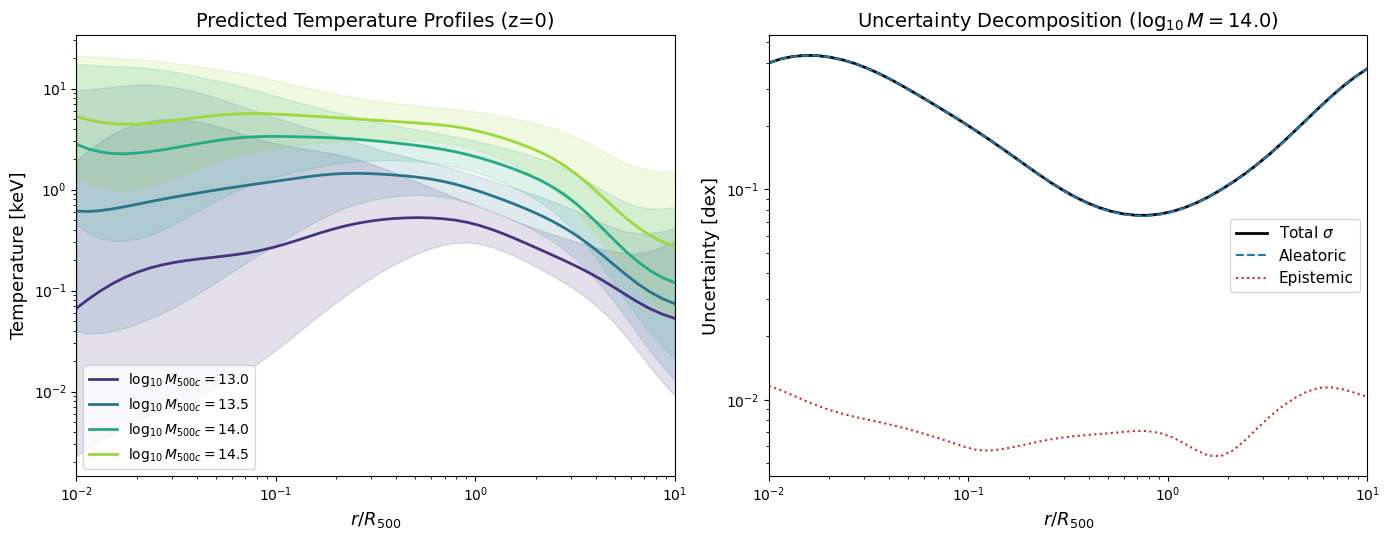

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(masses)))

# --- Panel 1: Temperature profiles ---
ax = axes[0]
for i, (lm, color) in enumerate(zip(log_masses, colors)):
    mu = pred_T.mean[i]
    # Use log-space bands: 10^(mu_log ± 2*sigma_log) — avoids delta-method inflation
    mu_log = pred_T.mean_log10[i]
    std_log = pred_T.std_log10[i]
    lower = 10 ** (mu_log - 2 * std_log)
    upper = 10 ** (mu_log + 2 * std_log)
    ax.plot(r_over_r500, mu, color=color, lw=2, label=f"$\\log_{{10}} M_{{500c}} = {lm:.1f}$")
    ax.fill_between(r_over_r500, lower, upper, alpha=0.15, color=color)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$r / R_{500}$", fontsize=13)
ax.set_ylabel("Temperature [keV]", fontsize=13)
ax.set_title("Predicted Temperature Profiles (z=0)", fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(r_over_r500[0], r_over_r500[-1])

# --- Panel 2: Uncertainty decomposition (in log10 / dex space) ---
ax = axes[1]
i_ref = 2  # 10^14 M☉ halo
ax.plot(r_over_r500, pred_T.std_log10[i_ref], 'k-', lw=2, label="Total $\\sigma$")
# Back-convert aleatoric/epistemic from physical to log-space: σ_log = σ_phys / (ln10 * T)
ln10 = np.log(10.0)
ale_log = pred_T.aleatoric_std[i_ref] / (ln10 * pred_T.mean[i_ref])
epi_log = pred_T.epistemic_std[i_ref] / (ln10 * pred_T.mean[i_ref])
ax.plot(r_over_r500, ale_log, 'C0--', lw=1.5, label="Aleatoric")
ax.plot(r_over_r500, epi_log, 'C3:', lw=1.5, label="Epistemic")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$r / R_{500}$", fontsize=13)
ax.set_ylabel("Uncertainty [dex]", fontsize=13)
ax.set_title(f"Uncertainty Decomposition ($\\log_{{10}} M = {log_masses[i_ref]:.1f}$)", fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(r_over_r500[0], r_over_r500[-1])

plt.tight_layout()
plt.show()

## 7.5 Predict All Channels Simultaneously

The multi-channel mode returns all predicted fields at once:

In [22]:
# Request all available fields at once
all_fields = emu.available_fields()
print(f"Predicting fields: {all_fields}")

pred_all = emu.predict(
    theta=theta_fiducial,
    M=masses,
    r_bins=r_over_r500,
    field=all_fields,
    snapnum=90,
    n_samples=50,
)

print(f"\nOutput shape: {pred_all.mean.shape}")
print(f"  → (n_halo={len(masses)}, n_r={len(r_over_r500)}, n_fields={len(all_fields)})")

Predicting fields: ['gas_density', 'temperature', 'pressure']

Output shape: (4, 50, 3)
  → (n_halo=4, n_r=50, n_fields=3)


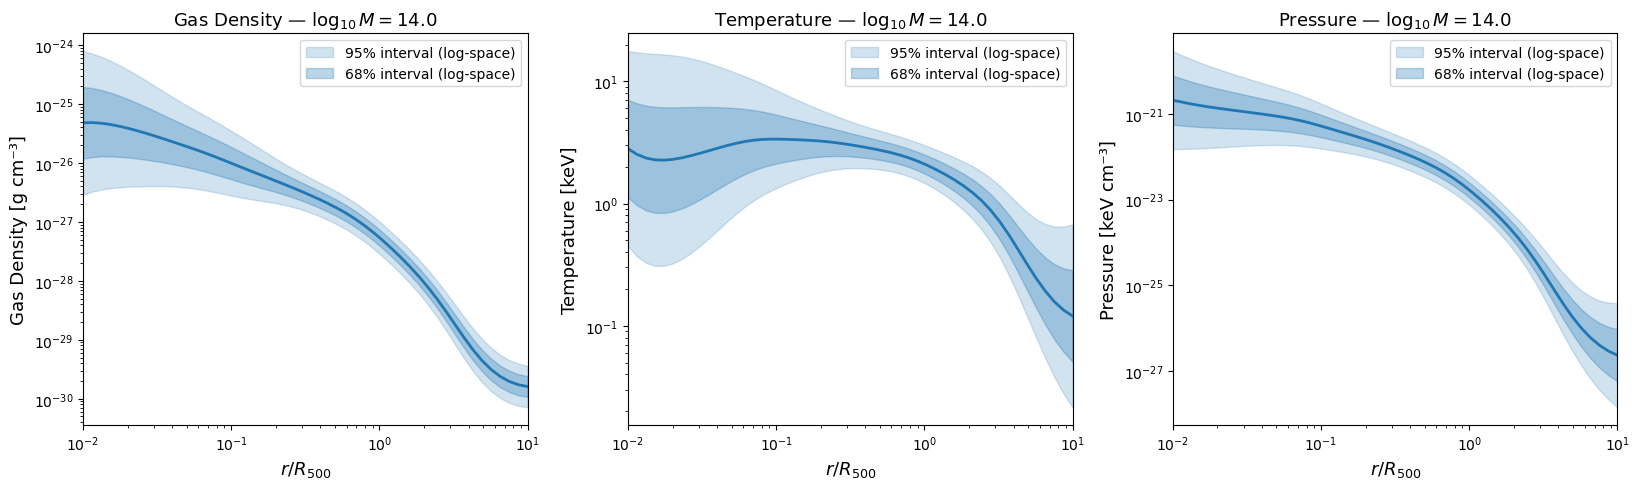

In [23]:
# Plot all channels for a single halo mass
field_labels = {
    'temperature': ('Temperature', 'keV'),
    'pressure': ('Pressure', 'keV cm⁻³'),
    'gas_density': ('Gas Density', 'g cm⁻³'),
}

i_halo = 2  # 10^14 M☉
n_fields = len(all_fields)
fig, axes = plt.subplots(1, n_fields, figsize=(5.5 * n_fields, 5))
if n_fields == 1:
    axes = [axes]

for k, (fname, ax) in enumerate(zip(all_fields, axes)):
    mu = pred_all.mean[i_halo, :, k]

    # Prefer multiplicative/log-space intervals on log-y plots to avoid
    # inflated-looking additive bands near zero.
    if pred_all.mean_log10 is not None and pred_all.std_log10 is not None:
        mu_log = pred_all.mean_log10[i_halo, :, k]
        std_log = pred_all.std_log10[i_halo, :, k]
        lo_1s = 10.0 ** (mu_log - std_log)
        hi_1s = 10.0 ** (mu_log + std_log)
        lo_2s = 10.0 ** (mu_log - 2.0 * std_log)
        hi_2s = 10.0 ** (mu_log + 2.0 * std_log)
        band_label_1s = '68% interval (log-space)'
        band_label_2s = '95% interval (log-space)'
    else:
        std = pred_all.total_std[i_halo, :, k]
        tiny = np.finfo(float).tiny
        lo_1s = np.clip(mu - std, tiny, None)
        hi_1s = mu + std
        lo_2s = np.clip(mu - 2.0 * std, tiny, None)
        hi_2s = mu + 2.0 * std
        band_label_1s = '±1σ'
        band_label_2s = '±2σ'

    ax.plot(r_over_r500, mu, 'C0-', lw=2)
    ax.fill_between(r_over_r500, lo_2s, hi_2s, alpha=0.2, color='C0', label=band_label_2s)
    ax.fill_between(r_over_r500, lo_1s, hi_1s, alpha=0.3, color='C0', label=band_label_1s)

    label, units = field_labels.get(fname, (fname, ''))
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('$r / R_{500}$', fontsize=13)
    ax.set_ylabel(f'{label} [{units}]' if units else label, fontsize=13)
    ax.set_title(f'{label} — $\\log_{{10}} M = {log_masses[i_halo]:.1f}$', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(r_over_r500[0], r_over_r500[-1])

plt.tight_layout()
plt.show()

## 7.6 Exploring Parameter Dependence

A key advantage of the emulator: we can rapidly explore how profiles change across the parameter space. Let's vary one feedback parameter while keeping others fixed.

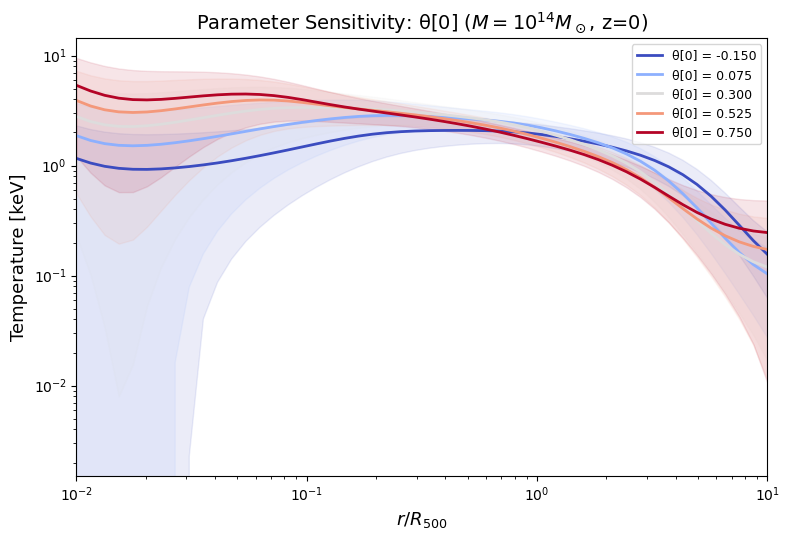

In [24]:
# Vary the first astrophysical parameter (index 2 in theta = Omega_m, sigma_8, ASN1, ...)
# We'll vary the 3rd parameter (ASN1 — SN feedback strength)
param_idx = 0  # 0-indexed within theta
param_values = np.linspace(
    theta_fiducial[param_idx] - 1.5 * abs(theta_fiducial[param_idx]),
    theta_fiducial[param_idx] + 1.5 * abs(theta_fiducial[param_idx]),
    5
)

M_single = np.array([1e14])  # single 10^14 M☉ halo

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(param_values)))

for j, (pval, color) in enumerate(zip(param_values, colors)):
    theta_var = theta_fiducial.copy()
    theta_var[param_idx] = pval

    pred_j = emu.predict(
        theta=theta_var,
        M=M_single,
        r_bins=r_over_r500,
        field="temperature",
        snapnum=90,
        n_samples=30,
    )

    ax.plot(r_over_r500, pred_j.mean[0], color=color, lw=2,
            label=f"θ[{param_idx}] = {pval:.3f}")
    ax.fill_between(r_over_r500,
                    pred_j.mean[0] - pred_j.total_std[0],
                    pred_j.mean[0] + pred_j.total_std[0],
                    alpha=0.1, color=color)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$r / R_{500}$', fontsize=13)
ax.set_ylabel('Temperature [keV]', fontsize=13)
ax.set_title(f'Parameter Sensitivity: θ[{param_idx}] ($M = 10^{{14}} M_\\odot$, z=0)', fontsize=14)
ax.legend(fontsize=9, loc='best')
ax.set_xlim(r_over_r500[0], r_over_r500[-1])
plt.tight_layout()
plt.show()

### 7.6.1 One-at-a-Time (1P) Validation Against Simulations

The parameter sweep above explores the emulator's predictions in isolation. A stronger test compares against the **CAMELS 1P simulation suite**, where each run varies exactly one parameter from the fiducial. For each parameter and variation level we plot the **ratio of the varied profile to the fiducial** — if the emulator captures parameter sensitivity correctly, the predicted ratios (lines) should track the true simulation ratios (points with error bars).

> **Note:** This requires access to the 1P test profile files on disk.

In [25]:
import re
import pandas as pd

# ---- 1P test profile directory and parameter table ----
ONEP_PROFILE_DIR = Path('/mnt/home/mlee1/ceph/Profiles_cy_test')
ONEP_PARAM_CSV   = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
ONEP_FIELDS      = [f for f in emu.available_fields()]  # all channels the model knows
ONEP_SNAPNUM     = 90
ONEP_NSAMPLES    = 30
ONEP_MASS_CUT    = 1e12

# Load 1P parameter table
onep_params = pd.read_csv(ONEP_PARAM_CSV, sep=r'\s+', engine='python')
if '#Name' in onep_params.columns:
    onep_params = onep_params.rename(columns={'#Name': 'tag'})

# Identify theta columns matching the emulator's input dimension
numeric_cols = [c for c in onep_params.columns
                if c != 'tag' and pd.api.types.is_numeric_dtype(onep_params[c])
                and str(c).strip().lower() != 'seed']
theta_cols_1p = numeric_cols[:emu.theta_dim]

# Discover available 1P profile files  →  tag -> {snap: filepath}
onep_file_map = {}
pat_1p = re.compile(r'IllustrisTNG_(1P_.+)_snap(\d+)\.npz$')
for fp in sorted(ONEP_PROFILE_DIR.glob('IllustrisTNG_1P_*_snap*.npz')):
    m = pat_1p.match(fp.name)
    if m:
        onep_file_map.setdefault(m.group(1), {})[int(m.group(2))] = fp

# Keep tags that have both a theta row and a profile file for the chosen snap
onep_tags = sorted(
    t for t in set(onep_params['tag'].astype(str)) & set(onep_file_map)
    if ONEP_SNAPNUM in onep_file_map[t]
)
print(f'1P tags with params + profiles at snap {ONEP_SNAPNUM}: {len(onep_tags)}')

1P tags with params + profiles at snap 90: 129


In [26]:

# Cache 1P predictions for one chosen snapshot and build family-grid plotting helper.
def build_onep_cache_for_snap(snapnum=None, fields=None, n_samples=None):
    snapnum = int(ONEP_SNAPNUM if snapnum is None else snapnum)
    fields = list(ONEP_REQUESTED_FIELDS if fields is None else fields)
    n_samples = int(ONEP_NSAMPLES if n_samples is None else n_samples)

    missing_fields = [f for f in fields if f not in set(emu.available_fields())]
    if missing_fields:
        raise ValueError(f'Requested fields not available in emulator: {missing_fields}')

    onep_cache = {}
    summary_rows = []
    skipped = []

    for tag in onep_tags:
        fp = onep_file_map.get(tag, {}).get(snapnum, None)
        if fp is None:
            skipped.append(tag)
            continue

        row = onep_params[onep_params['tag'].astype(str) == str(tag)]
        if len(row) == 0:
            skipped.append(tag)
            continue

        theta_tag = row.iloc[0][theta_cols_1p].to_numpy(dtype=np.float32)

        with np.load(fp) as dat:
            masses = np.asarray(dat['M500c'], dtype=np.float32)
            radial_bins = np.asarray(dat['radial_bins'], dtype=np.float32)
            if 'R500c' not in dat:
                skipped.append(tag)
                continue
            r500c = np.asarray(dat['R500c'], dtype=np.float32)

            true_profiles = {}
            missing_truth = False
            for fld in fields:
                key = f'{fld}_array'
                if key not in dat:
                    missing_truth = True
                    break
                true_profiles[fld] = np.asarray(dat[key], dtype=np.float32)
            if missing_truth:
                skipped.append(tag)
                continue

        if masses.size == 0 or radial_bins.size == 0:
            skipped.append(tag)
            continue

        rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], np.float32(1e-12))).astype(np.float32)

        try:
            pred = emu.predict(
                theta=theta_tag,
                M=masses,
                r_bins=rr500,
                field=fields,
                snapnum=snapnum,
                n_samples=n_samples,
            )
        except TypeError:
            pred = emu.predict(
                theta=theta_tag,
                M=masses,
                r_bins=rr500,
                field=fields,
                n_samples=n_samples,
            )

        onep_cache[tag] = {
            'profile_file': str(fp),
            'snapnum': int(snapnum),
            'theta': theta_tag,
            'M500c': masses.astype(np.float64),
            'R500c': r500c.astype(np.float64),
            'radial_bins': radial_bins.astype(np.float64),
            'true_profiles': {k: v.astype(np.float64) for k, v in true_profiles.items()},
            'pred': pred,
        }

        summary_rows.append({
            'tag': str(tag),
            'snap': int(snapnum),
            'n_halos': int(masses.shape[0]),
            'n_r': int(radial_bins.shape[0]),
            'profile_file': Path(fp).name,
        })

    summary_df = pd.DataFrame(summary_rows).sort_values('tag').reset_index(drop=True)
    return onep_cache, summary_df, skipped


def plot_onep_family_grid_test(
    onep_cache,
    base_params=None,
    field='pressure',
    mass_cut=ONEP_MASS_CUT,
    variation_suffixes=('n2', 'n1', '1', '2'),
    n_cols=6,
    max_rows=None,
):
    import re

    if not isinstance(onep_cache, dict) or len(onep_cache) == 0:
        raise RuntimeError('onep_cache is empty. Build cache first.')

    if base_params is None:
        pat = re.compile(r'^1P_(.+)_.+$')
        base_params = sorted({pat.match(t).group(1) for t in onep_cache if pat.match(t)})
    base_params = [str(p) for p in base_params]
    if max_rows is not None:
        base_params = base_params[: int(max_rows)]

    variation_suffixes = [str(s) for s in variation_suffixes]
    if len(variation_suffixes) != 4:
        raise ValueError('variation_suffixes must have exactly 4 entries')

    n_params = len(base_params)
    if n_params == 0:
        raise RuntimeError('No base parameters found to plot')

    n_cols = int(max(1, n_cols))
    n_rows = int(np.ceil(n_params / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.8 * n_cols, 2.7 * n_rows),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    colors = plt.cm.seismic(np.linspace(0, 1, 4))

    def _extract_field(pred_obj, field_name):
        names = list(pred_obj.field_names)
        if field_name not in names:
            return None
        j = names.index(field_name)
        mu = np.asarray(pred_obj.mean, dtype=np.float64)
        if mu.ndim == 3:
            return mu[:, :, j]
        if mu.ndim == 2 and len(names) == 1 and names[0] == field_name:
            return mu
        return None

    eps = 1e-30

    for i, base in enumerate(base_params):
        ax = axes[i // n_cols, i % n_cols]
        fid_tag = f'1P_{base}_0'
        fid = onep_cache.get(fid_tag, None)

        ax.set_xscale('log')
        if i % n_cols == 0:
            ax.set_ylabel('variation / fiducial', fontsize=8)
        if i // n_cols == n_rows - 1:
            ax.set_xlabel('radius [kpc]', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_title(base, fontsize=8)

        if fid is None:
            ax.text(0.5, 0.5, 'missing fiducial', ha='center', va='center', transform=ax.transAxes, fontsize=7)
            continue

        m_fid = np.asarray(fid['M500c'], dtype=np.float64)
        r_kpc = np.asarray(fid['radial_bins'], dtype=np.float64)
        true_fid_all = np.asarray(fid['true_profiles'][field], dtype=np.float64)
        pred_fid_all = _extract_field(fid['pred'], field)

        if pred_fid_all is None:
            ax.text(0.5, 0.5, 'missing fiducial field', ha='center', va='center', transform=ax.transAxes, fontsize=7)
            continue

        mask_fid = np.isfinite(m_fid) & (m_fid >= float(mass_cut))
        if np.count_nonzero(mask_fid) == 0:
            ax.text(0.5, 0.5, 'no high-mass fid halos', ha='center', va='center', transform=ax.transAxes, fontsize=7)
            continue

        true_fid = np.median(np.clip(true_fid_all[mask_fid], eps, None), axis=0)
        pred_fid = np.median(np.clip(pred_fid_all[mask_fid], eps, None), axis=0)

        for sfx, color in zip(variation_suffixes, colors):
            tag = f'1P_{base}_{sfx}'
            rec = onep_cache.get(tag, None)
            if rec is None:
                continue

            m_var = np.asarray(rec['M500c'], dtype=np.float64)
            true_var_all = np.asarray(rec['true_profiles'][field], dtype=np.float64)
            pred_var_all = _extract_field(rec['pred'], field)
            if pred_var_all is None:
                continue

            mask_var = np.isfinite(m_var) & (m_var >= float(mass_cut))
            if np.count_nonzero(mask_var) == 0:
                continue

            true_var = np.median(np.clip(true_var_all[mask_var], eps, None), axis=0)
            pred_var = np.median(np.clip(pred_var_all[mask_var], eps, None), axis=0)

            ratio_true = true_var / np.clip(true_fid, eps, None)
            ratio_pred = pred_var / np.clip(pred_fid, eps, None)

            step = max(1, int(r_kpc.size // 12))
            idx = np.arange(0, r_kpc.size, step)
            ax.plot(r_kpc, ratio_pred, color=color, lw=1.2)
            ax.errorbar(
                r_kpc[idx],
                ratio_true[idx],
                yerr=np.zeros_like(idx, dtype=np.float64),
                fmt='o',
                ms=2.0,
                lw=0.6,
                color=color,
                alpha=0.5,
            )

        ax.axhline(1.0, color='k', lw=0.8, alpha=0.55)

    for k in range(n_params, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].set_visible(False)

    legend_handles = [
        plt.Line2D([0], [0], color='k', lw=1.5, label='model ratio'),
        plt.Line2D([0], [0], color='k', marker='o', linestyle='None', markersize=4, label='truth ratio (sampled points)'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(f'1P family grid | field={field}, mass>= {mass_cut:.2e}', y=1.06)
    plt.show()

In [27]:
# Enhanced 1P family-grid plotting:
# 1) true-point error bars, 2) natural parameter ordering (p1, p2, ...), 3) explicit snapshot/redshift selection.

def build_onep_cache_by_snap(snapnums, fields=None, n_samples=None):
    """Build and return a cache dict keyed by snapshot number."""
    snapnums = [int(s) for s in snapnums]
    out = {}
    summary_rows = []
    skipped_by_snap = {}

    for snap in snapnums:
        cache_i, summary_i, skipped_i = build_onep_cache_for_snap(
            snapnum=int(snap),
            fields=fields,
            n_samples=n_samples,
        )
        out[int(snap)] = cache_i
        skipped_by_snap[int(snap)] = list(skipped_i)

        if len(summary_i) > 0:
            s = summary_i.copy()
            s['snap'] = int(snap)
            summary_rows.append(s)

    if len(summary_rows) > 0:
        summary_df = pd.concat(summary_rows, ignore_index=True)
    else:
        summary_df = pd.DataFrame(columns=['tag', 'snap', 'n_halos', 'n_r', 'profile_file'])

    return out, summary_df, skipped_by_snap


def _natural_base_param_order(base_params):
    import re

    def _key(x):
        s = str(x)
        m = re.fullmatch(r'p(\d+)', s)
        if m is not None:
            return (0, int(m.group(1)))
        return (1, s)

    return sorted([str(p) for p in base_params], key=_key)


def plot_onep_family_grid_test(
    onep_cache,
    base_params=None,
    field='pressure',
    mass_cut=ONEP_MASS_CUT,
    variation_suffixes=('n2', 'n1', '1', '2'),
    n_cols=6,
    max_rows=None,
    snapnum=None,
    onep_cache_by_snap=None,
    fiducial_tag='1P_p1_0',
):
    import re

    if onep_cache_by_snap is not None:
        if snapnum is None:
            raise ValueError('When onep_cache_by_snap is provided, snapnum must also be provided.')
        snapnum = int(snapnum)
        if snapnum not in onep_cache_by_snap:
            raise KeyError(f'Snapshot {snapnum} not found in onep_cache_by_snap. Available: {sorted(onep_cache_by_snap.keys())}')
        cache = onep_cache_by_snap[snapnum]
    else:
        cache = onep_cache

    if not isinstance(cache, dict) or len(cache) == 0:
        raise RuntimeError('Selected onep cache is empty. Build cache first.')

    if fiducial_tag not in cache:
        raise KeyError(f'Missing required global fiducial tag: {fiducial_tag}')

    if base_params is None:
        pat = re.compile(r'^1P_(.+)_.+$')
        base_params = sorted({pat.match(t).group(1) for t in cache if pat.match(t)})
    base_params = _natural_base_param_order(base_params)
    if max_rows is not None:
        base_params = base_params[: int(max_rows)]

    variation_suffixes = [str(s) for s in variation_suffixes]
    if len(variation_suffixes) != 4:
        raise ValueError('variation_suffixes must have exactly 4 entries')

    n_params = len(base_params)
    if n_params == 0:
        raise RuntimeError('No base parameters found to plot')

    n_cols = int(max(1, n_cols))
    n_rows = int(np.ceil(n_params / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.8 * n_cols, 2.9 * n_rows),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    colors = plt.cm.seismic(np.linspace(0, 1, 4))

    def _extract_field(pred_obj, field_name):
        names = list(pred_obj.field_names)
        if field_name not in names:
            return None
        j = names.index(field_name)
        mu = np.asarray(pred_obj.mean, dtype=np.float64)
        if mu.ndim == 3:
            return mu[:, :, j]
        if mu.ndim == 2 and len(names) == 1 and names[0] == field_name:
            return mu
        return None

    def _median_and_err(arr_2d):
        # Robust uncertainty proxy for the median at each radius bin.
        arr_2d = np.asarray(arr_2d, dtype=np.float64)
        med = np.nanmedian(arr_2d, axis=0)
        n = np.sum(np.isfinite(arr_2d), axis=0).astype(np.float64)
        mad = np.nanmedian(np.abs(arr_2d - med[None, :]), axis=0)
        sigma_rob = 1.4826 * mad
        err = 1.2533 * sigma_rob / np.sqrt(np.maximum(n, 1.0))
        err[~np.isfinite(err)] = 0.0
        return med, err

    eps = 1e-30
    fid = cache[fiducial_tag]

    m_fid = np.asarray(fid['M500c'], dtype=np.float64)
    r_kpc = np.asarray(fid['radial_bins'], dtype=np.float64)
    true_fid_all = np.asarray(fid['true_profiles'][field], dtype=np.float64)
    pred_fid_all = _extract_field(fid['pred'], field)

    if pred_fid_all is None:
        raise RuntimeError(f"Fiducial prediction does not contain field '{field}'.")

    mask_fid = np.isfinite(m_fid) & (m_fid >= float(mass_cut))
    if np.count_nonzero(mask_fid) == 0:
        mask_fid = np.isfinite(m_fid) & (m_fid > 0.0)
        if np.count_nonzero(mask_fid) == 0:
            raise RuntimeError('No valid fiducial halos available for plotting.')
        print(f"Warning: no fiducial halos satisfy mass_cut={mass_cut:.3e}; using all finite fiducial halos instead.")

    true_fid_med, true_fid_err = _median_and_err(np.clip(true_fid_all[mask_fid], eps, None))
    pred_fid_med, _ = _median_and_err(np.clip(pred_fid_all[mask_fid], eps, None))

    for i, base in enumerate(base_params):
        ax = axes[i // n_cols, i % n_cols]

        ax.set_xscale('log')
        if i % n_cols == 0:
            ax.set_ylabel('variation / fiducial', fontsize=8)
        if i // n_cols == n_rows - 1:
            ax.set_xlabel('radius [kpc]', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_title(base, fontsize=8)

        for sfx, color in zip(variation_suffixes, colors):
            tag = f'1P_{base}_{sfx}'
            rec = cache.get(tag, None)
            if rec is None:
                continue

            m_var = np.asarray(rec['M500c'], dtype=np.float64)
            true_var_all = np.asarray(rec['true_profiles'][field], dtype=np.float64)
            pred_var_all = _extract_field(rec['pred'], field)
            if pred_var_all is None:
                continue

            mask_var = np.isfinite(m_var) & (m_var >= float(mass_cut))
            if np.count_nonzero(mask_var) == 0:
                mask_var = np.isfinite(m_var) & (m_var > 0.0)
                if np.count_nonzero(mask_var) == 0:
                    continue

            true_var_med, true_var_err = _median_and_err(np.clip(true_var_all[mask_var], eps, None))
            pred_var_med, _ = _median_and_err(np.clip(pred_var_all[mask_var], eps, None))

            ratio_true = true_var_med / np.clip(true_fid_med, eps, None)
            ratio_pred = pred_var_med / np.clip(pred_fid_med, eps, None)

            # Propagate uncertainty for true ratio from numerator and denominator medians.
            frac_var = true_var_err / np.clip(np.abs(true_var_med), eps, None)
            frac_fid = true_fid_err / np.clip(np.abs(true_fid_med), eps, None)
            ratio_true_err = np.abs(ratio_true) * np.sqrt(frac_var ** 2 + frac_fid ** 2)

            step = max(1, int(r_kpc.size // 12))
            idx = np.arange(0, r_kpc.size, step)
            if len(idx) == 0 or idx[-1] != (r_kpc.size - 1):
                idx = np.unique(np.append(idx, r_kpc.size - 1))

            ax.plot(r_kpc, ratio_pred, color=color, lw=1.2)
            ax.errorbar(
                r_kpc[idx],
                ratio_true[idx],
                yerr=ratio_true_err[idx],
                fmt='o',
                ms=2.2,
                lw=0.7,
                elinewidth=0.7,
                capsize=1.6,
                color=color,
                alpha=0.55,
            )

        ax.axhline(1.0, color='k', lw=0.8, alpha=0.55)

    for k in range(n_params, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].set_visible(False)

    snap_txt = f' | snap={int(snapnum)}' if snapnum is not None else ''
    fig.suptitle(f'1P family grid | field={field}, mass>= {mass_cut:.2e}{snap_txt}', y=1.04)

    legend_handles = [
        plt.Line2D([0], [0], color='k', lw=1.5, label='model ratio'),
        plt.Line2D([0], [0], color='k', marker='o', linestyle='None', markersize=4, label='true ratio ± error'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.01))
    plt.show()

In [30]:
ONEP_REQUESTED_FIELDS = ['pressure', 'temperature', 'gas_density']


Built cache for snapshot 90: 129 tags
Skipped tags: 0


,tag,snap,n_halos,n_r,profile_file
0,1P_p10_1,90,124,30,IllustrisTNG_1P_p10_1_snap090.npz
1,1P_p10_2,90,126,30,IllustrisTNG_1P_p10_2_snap090.npz
2,1P_p10_n1,90,124,30,IllustrisTNG_1P_p10_n1_snap090.npz
3,1P_p10_n2,90,122,30,IllustrisTNG_1P_p10_n2_snap090.npz
4,1P_p11_1,90,124,30,IllustrisTNG_1P_p11_1_snap090.npz
5,1P_p11_2,90,127,30,IllustrisTNG_1P_p11_2_snap090.npz
6,1P_p11_n1,90,124,30,IllustrisTNG_1P_p11_n1_snap090.npz
7,1P_p11_n2,90,123,30,IllustrisTNG_1P_p11_n2_snap090.npz
8,1P_p12_1,90,122,30,IllustrisTNG_1P_p12_1_snap090.npz
9,1P_p12_2,90,119,30,IllustrisTNG_1P_p12_2_snap090.npz


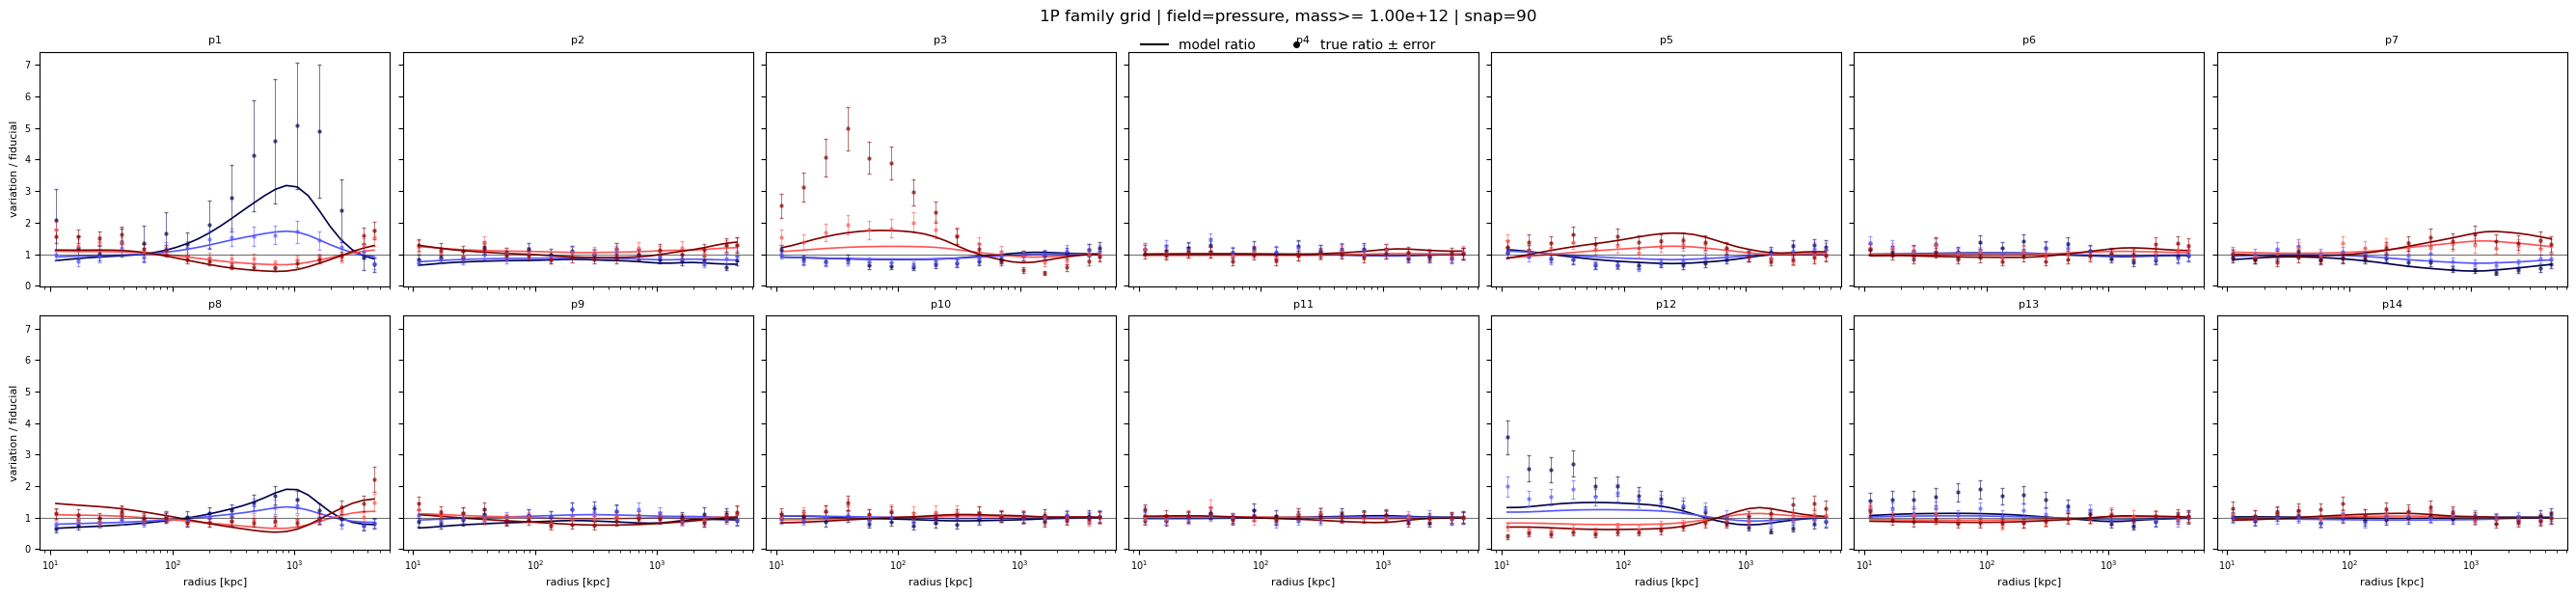

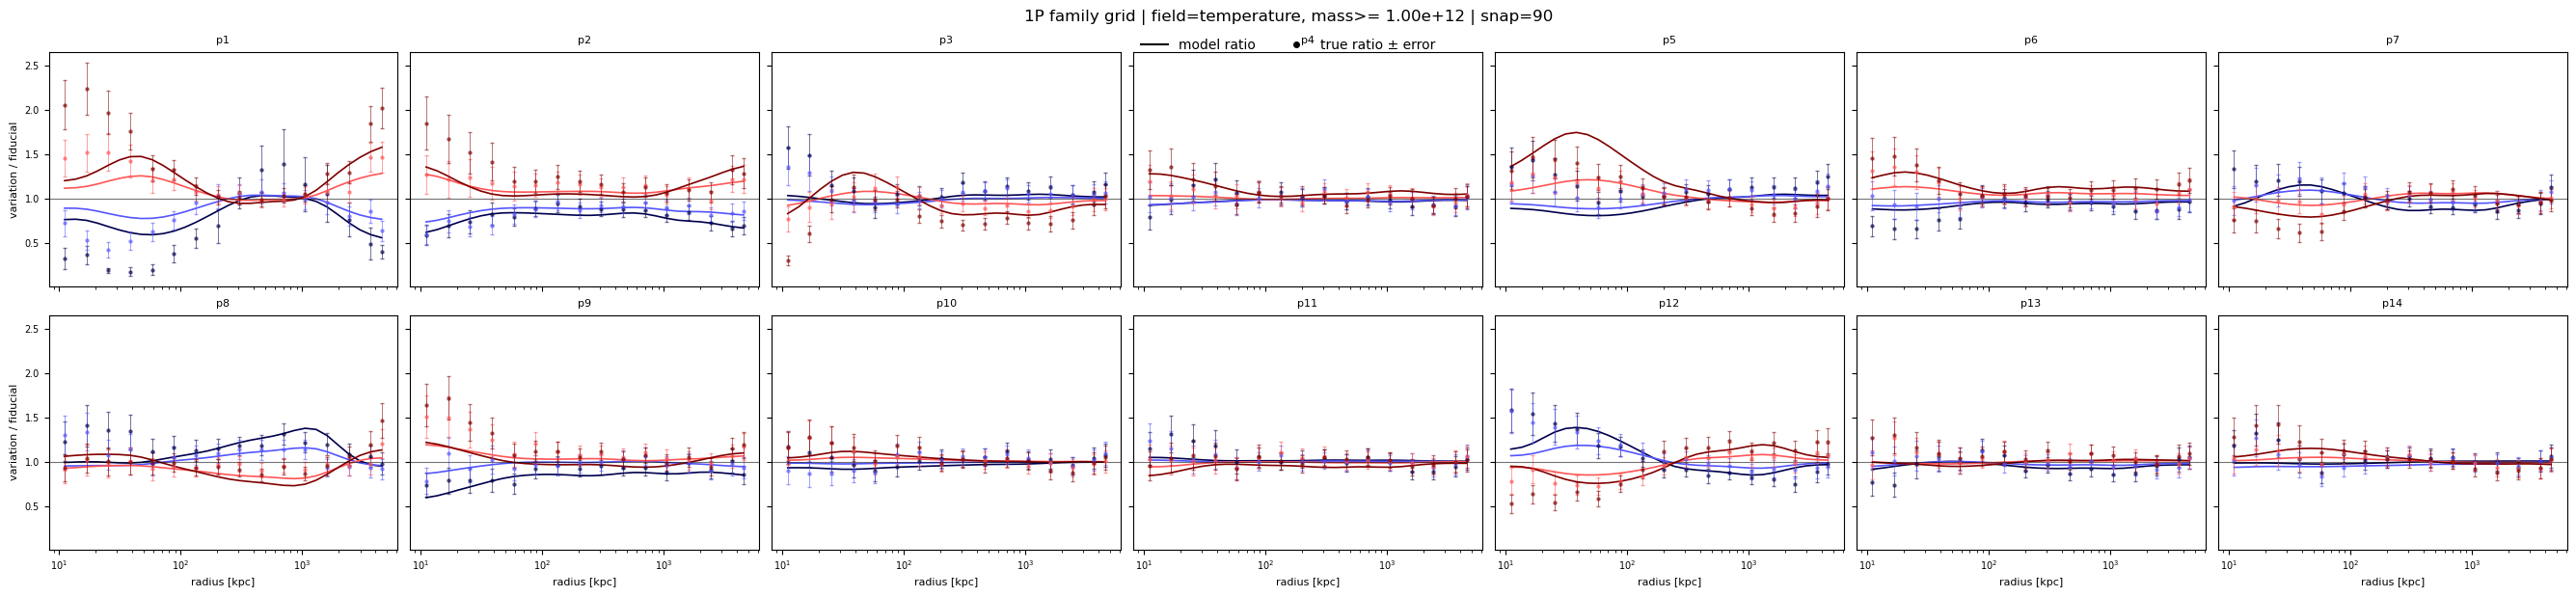

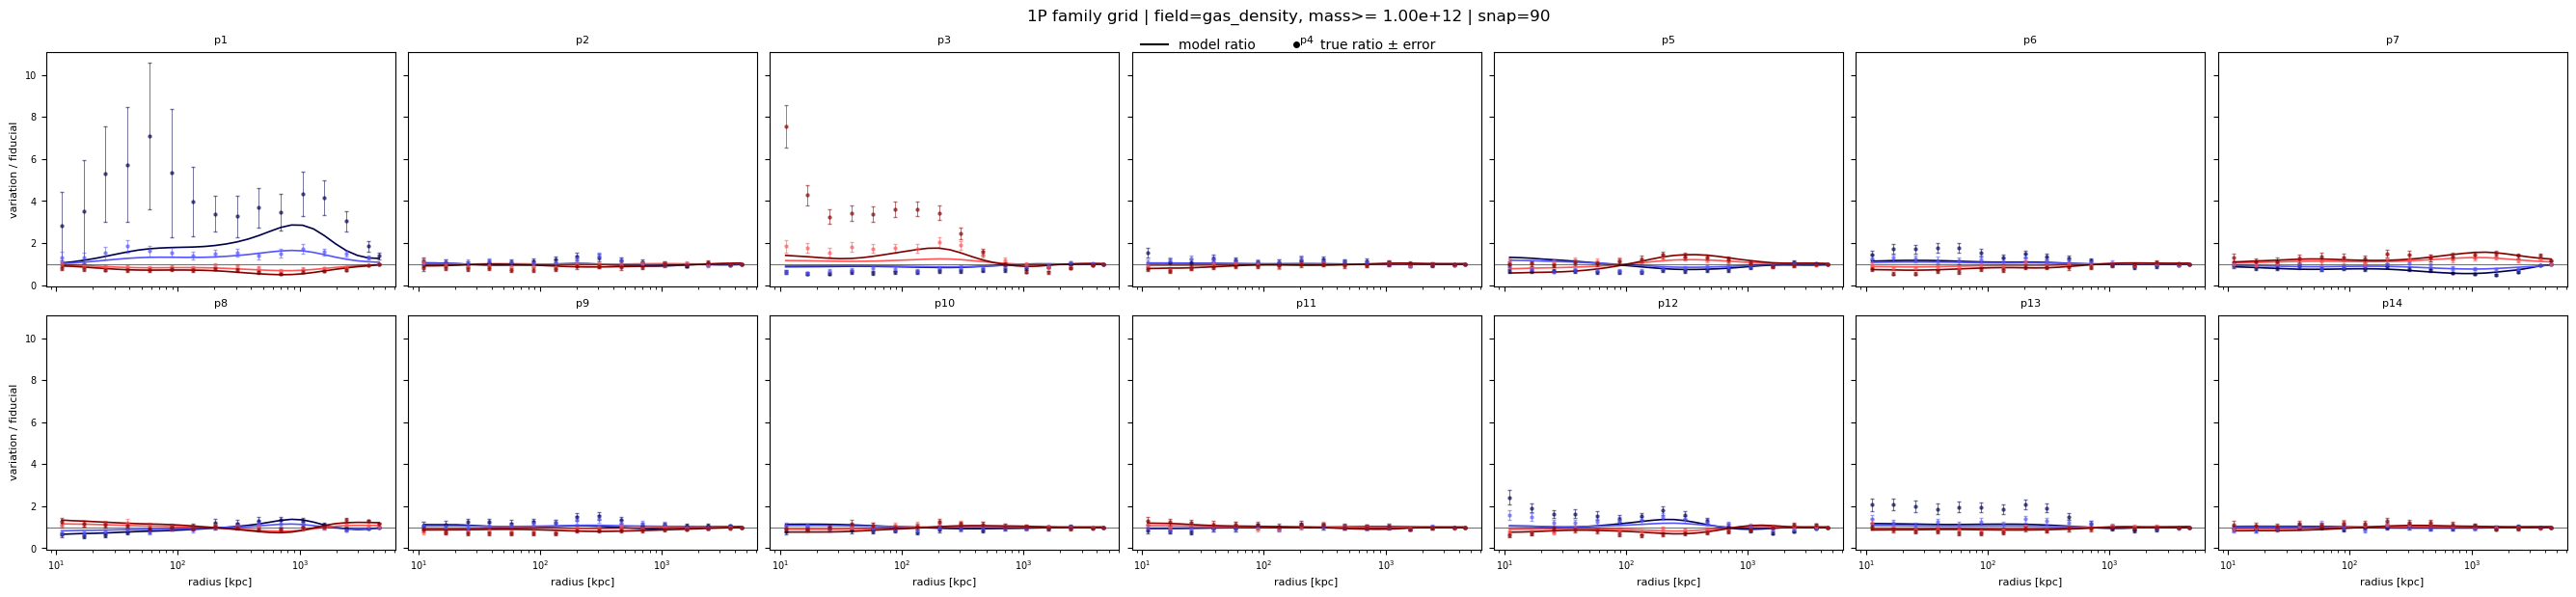

KeyError: 'metallicity'

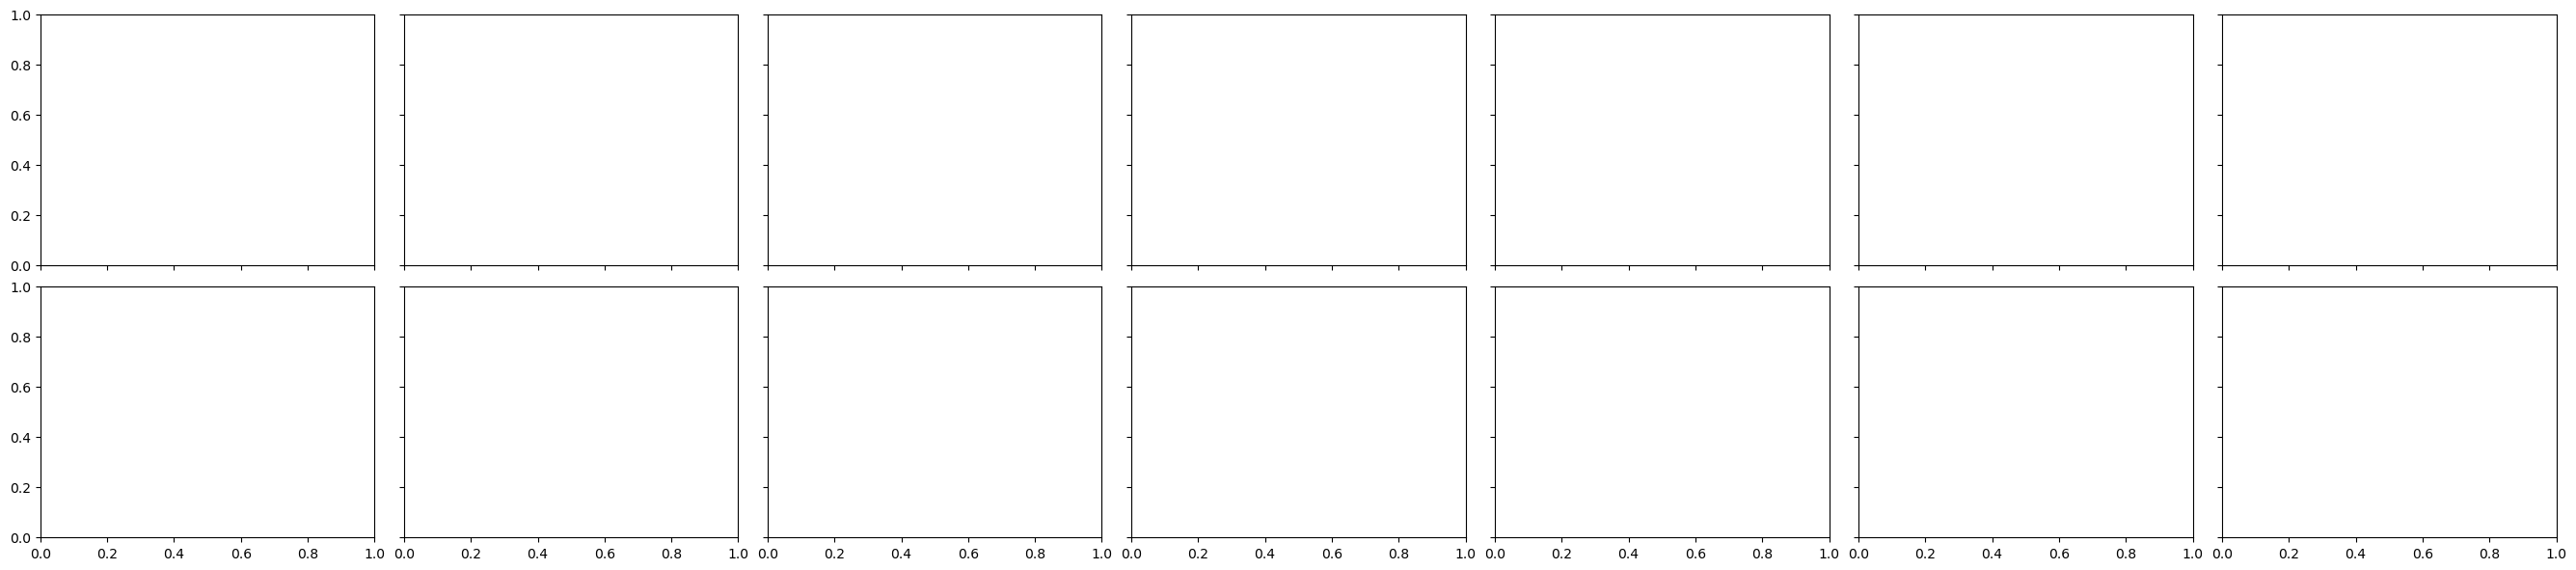

In [31]:
# Build cache for the single loaded snapshot and render family grids.
onep_cache, onep_summary_df, onep_skipped_tags = build_onep_cache_for_snap(
    snapnum=ONEP_SNAPNUM,
    fields=ONEP_REQUESTED_FIELDS,
    n_samples=ONEP_NSAMPLES,
)

print(f'Built cache for snapshot {ONEP_SNAPNUM}: {len(onep_cache)} tags')
print(f'Skipped tags: {len(onep_skipped_tags)}')
if len(onep_skipped_tags) > 0:
    print('First skipped tags:', onep_skipped_tags[:10])

display(onep_summary_df.head(12))

plot_onep_family_grid_test(onep_cache, field='pressure',    n_cols=7, max_rows=14, snapnum=ONEP_SNAPNUM)
plot_onep_family_grid_test(onep_cache, field='temperature', n_cols=7, max_rows=14, snapnum=ONEP_SNAPNUM)
plot_onep_family_grid_test(onep_cache, field='gas_density', n_cols=7, max_rows=14, snapnum=ONEP_SNAPNUM)
plot_onep_family_grid_test(onep_cache, field='metallicity', n_cols=7, max_rows=14, snapnum=ONEP_SNAPNUM)

## 7.7 Multi-Redshift Predictions

If the model was trained on multiple snapshots, we can predict profiles at different redshifts:

Available snapshots: [90, 74, 60, 44]
Redshift mapping:   {90: 0.0, 74: 0.5, 60: 1.0, 44: 2.0}


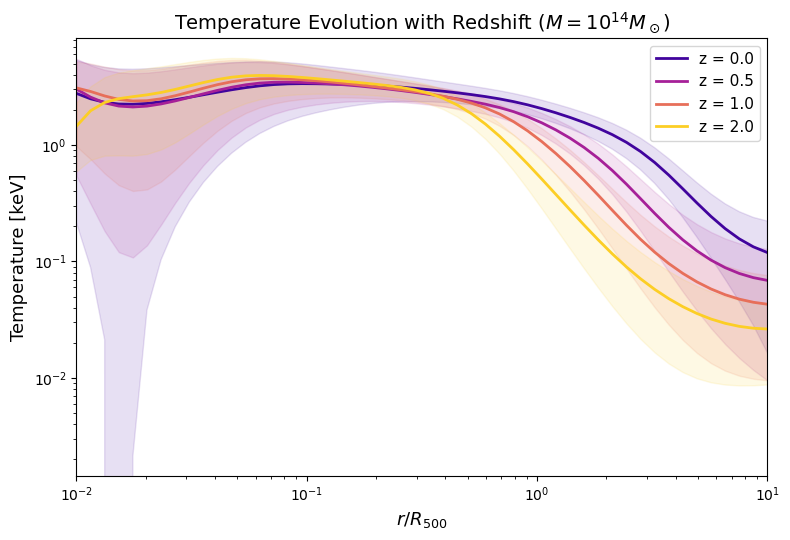

In [34]:
print(f"Available snapshots: {emu.snapnums}")
print(f"Redshift mapping:   {emu.redshift_by_snap}")

M_demo = np.array([1e14])

fig, ax = plt.subplots(figsize=(8, 5.5))
colors_z = plt.cm.plasma(np.linspace(0.1, 0.9, len(emu.snapnums)))

for snap, color in zip(emu.snapnums, colors_z):
    z_val = emu.redshift_by_snap.get(snap, None)
    label = f"z = {z_val:.1f}" if z_val is not None else f"snap {snap}"

    try:
        pred_z = emu.predict(
            theta=theta_fiducial,
            M=M_demo,
            r_bins=r_over_r500,
            field="temperature",
            snapnum=snap,
            n_samples=30,
        )
        ax.plot(r_over_r500, pred_z.mean[0], color=color, lw=2, label=label)
        ax.fill_between(r_over_r500,
                        pred_z.mean[0] - pred_z.total_std[0],
                        pred_z.mean[0] + pred_z.total_std[0],
                        alpha=0.12, color=color)
    except Exception as e:
        print(f"  Skipping snap {snap}: {e}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$r / R_{500}$', fontsize=13)
ax.set_ylabel('Temperature [keV]', fontsize=13)
ax.set_title('Temperature Evolution with Redshift ($M = 10^{14} M_\\odot$)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(r_over_r500[0], r_over_r500[-1])
plt.tight_layout()
plt.show()

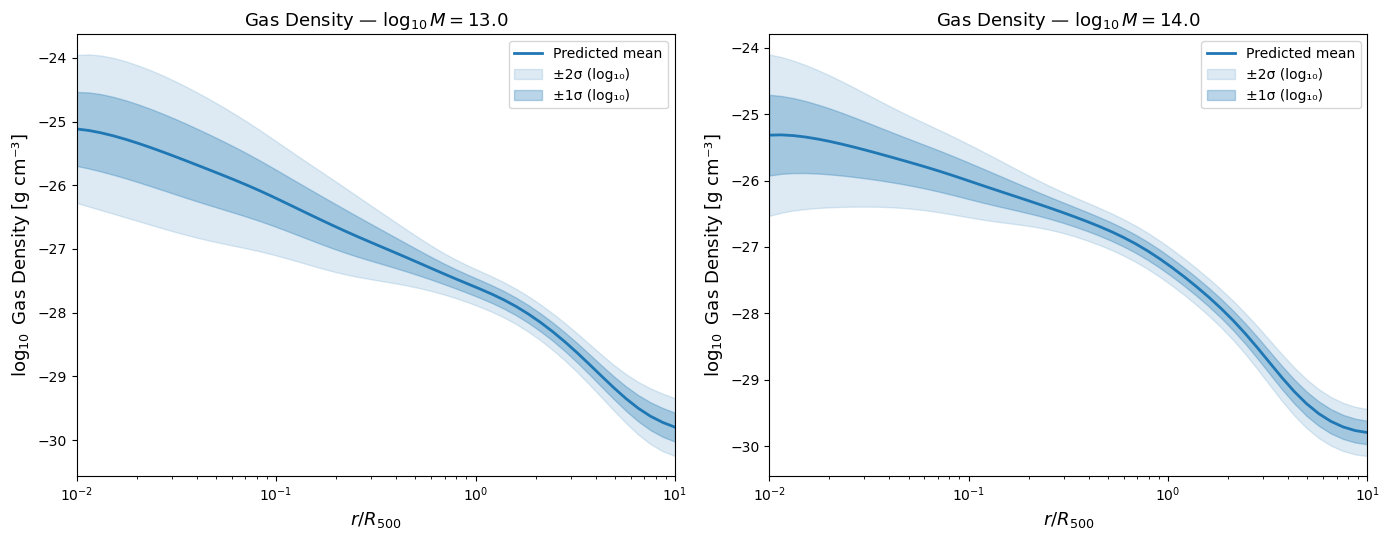

In [35]:
pred_rho = emu.predict(
    theta=theta_fiducial,
    M=np.array([1e13, 1e14]),
    r_bins=r_over_r500,
    field="gas_density",
    snapnum=90,
    n_samples=50,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for i_h, (lm, ax) in enumerate(zip([13.0, 14.0], axes)):
    # Log-space: symmetric bands
    if pred_rho.mean_log10 is not None:
        mu_log = pred_rho.mean_log10[i_h]
        std_log = pred_rho.std_log10[i_h]
        ax.plot(r_over_r500, mu_log, 'C0-', lw=2, label='Predicted mean')
        ax.fill_between(r_over_r500, mu_log - 2 * std_log, mu_log + 2 * std_log,
                        alpha=0.15, color='C0', label='±2σ (log₁₀)')
        ax.fill_between(r_over_r500, mu_log - std_log, mu_log + std_log,
                        alpha=0.3, color='C0', label='±1σ (log₁₀)')
        ax.set_ylabel('$\\log_{10}$ Gas Density [g cm⁻³]', fontsize=13)
    else:
        ax.plot(r_over_r500, pred_rho.mean[i_h], 'C0-', lw=2)
        ax.set_yscale('log')
        ax.set_ylabel('Gas Density [g cm⁻³]', fontsize=13)

    ax.set_xscale('log')
    ax.set_xlabel('$r / R_{500}$', fontsize=13)
    ax.set_title(f'Gas Density — $\\log_{{10}} M = {lm:.1f}$', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(r_over_r500[0], r_over_r500[-1])

plt.tight_layout()
plt.show()

---
## 8. Context Conditioning: Low-Mass Halos as Context for High-Mass Predictions

A hallmark of the Neural Process framework is **context conditioning**: given observed data points, the model can sharpen its predictions for unobserved points.

During **training**, each forward pass randomly splits a simulation's halos into context (observed) and target (predicted). The model learns two pathways:
- **Latent path**: encodes context into a global latent $z$ that shifts the predicted distribution
- **Cross-attention path**: each target query attends to context keys/values, gathering local information

During **emulation** (Section 7), we used **zero-shot** mode — no real context. The model fell back on its learned prior plus the mean model. But what happens when we condition on actual observed profiles?

**Experiment**: Take a held-out test simulation. Use the low-mass halos ($M < M_\text{split}$) as context — we "observe" their full profiles — and predict the high-mass halos ($M \geq M_\text{split}$). Compare to:
1. **Zero-shot** prediction (no context)
2. **Ground truth** from the simulation

In [36]:
# ── Load held-out test data ──────────────────────────────────────────
from types import SimpleNamespace
from train_anp_emulator import (
    build_tasks, split_tasks, normalize_tasks, compute_norm_stats,
    add_mean_back, denorm_y, restore_all_profiles_physical_units,
)

# Reconstruct the args used during training
args = SimpleNamespace(**dict(emu.args))

# build_tasks discovers all simulation runs and loads profiles
all_families = build_tasks(args)

# Reproduce the exact train/val/test split (deterministic given seed)
train_fam, val_fam, test_fam = split_tasks(
    all_families,
    train_frac=args.train_frac,
    val_frac=args.val_frac,
    seed=args.seed,
)
print(f"Train: {len(train_fam)}  Val: {len(val_fam)}  Test: {len(test_fam)} families")

# Compute normalization stats from train split (same as during training)
norm_stats = compute_norm_stats(
    train_fam,
    robust=bool(getattr(args, "robust_norm", False)),
    mass_redshift_aware=True,
)

# Normalize test families using train-set stats
test_fam_norm = normalize_tasks(test_fam, norm_stats)

Built 1021 run families (3998 snapshots) from 1024 discovered runs (skipped 3).
Example family run_id=0, snapshots=4, x=(150, 30, 38), y=(150, 30, 3)
Train: 816  Val: 102  Test: 103 families
[compute_norm_stats] Excluded 12999 zero-valued point-channels from y normalization stats.
[compute_norm_stats] Mass-redshift aware: 6 mass bins × 4 redshifts = 24 bins (19 with enough data).


In [37]:
# ── Pick a test family and split halos by mass ──────────────────────
# Choose a test family with a good range of halo masses.
best_fam_idx, best_fam_range = 0, 0.0
for fi, fam in enumerate(test_fam_norm):
    task = fam.snapshots[0]  # z=0 snapshot
    log_m = task.x[:, 0, 0]  # normalized log M — use raw for mass split
    raw_log_m = log_m * norm_stats["x_std"][0] + norm_stats["x_mean"][0]
    mrange = raw_log_m.max() - raw_log_m.min()
    if mrange > best_fam_range:
        best_fam_range = mrange
        best_fam_idx = fi

fam_norm = test_fam_norm[best_fam_idx]
fam_raw = test_fam[best_fam_idx]
task_norm = fam_norm.snapshots[0]  # normalized data for model input
task_raw = fam_raw.snapshots[0]    # unnormalized data for ground truth

# Raw (un-normalized) halo masses and radii
raw_log_m = task_raw.x[:, 0, 0]                   # log10(M500c)
raw_log_r = task_raw.x[0, :, 1]                    # log10(r/R500)
raw_theta = task_raw.x[0, 0, emu.theta_start_idx:emu.theta_start_idx + emu.theta_dim]

# Split: low-mass halos → context, high-mass halos → target
log_m_split = np.median(raw_log_m)
ctx_mask_halo = raw_log_m < log_m_split
tgt_mask_halo = raw_log_m >= log_m_split

n_ctx_halos = ctx_mask_halo.sum()
n_tgt_halos = tgt_mask_halo.sum()

print(f"Test family run_id={fam_raw.run_id}, snap={task_raw.snapnum}")
print(f"Total halos: {task_raw.n_halo}, radial bins: {task_raw.n_r}")
print(f"Mass range: [{raw_log_m.min():.2f}, {raw_log_m.max():.2f}] log10(M500c)")
print(f"Split at log10(M) = {log_m_split:.2f}")
print(f"  Context (low-mass):  {n_ctx_halos} halos")
print(f"  Target  (high-mass): {n_tgt_halos} halos")

Test family run_id=636, snap=90
Total halos: 150, radial bins: 30
Mass range: [12.36, 14.72] log10(M500c)
Split at log10(M) = 12.68
  Context (low-mass):  75 halos
  Target  (high-mass): 75 halos


In [38]:
# ── Context-conditioned vs zero-shot predictions ────────────────────
#
# We build a custom batch where context = low-mass halos (with their
# true profiles) and target = high-mass halos, then compare to the
# standard zero-shot emulator prediction.

x_norm = task_norm.x   # (n_halo, n_r, x_dim) — normalized
y_norm = task_norm.y   # (n_halo, n_r, y_dim) — normalized residuals

snap_idx = task_norm.snap_idx
n_r = task_norm.n_r
y_dim = y_norm.shape[-1]
x_dim = x_norm.shape[-1]

# Context: all radial bins of low-mass halos (flattened)
ctx_x_t = torch.tensor(x_norm[ctx_mask_halo].reshape(-1, x_dim), dtype=torch.float32).unsqueeze(0)
ctx_y_t = torch.tensor(y_norm[ctx_mask_halo].reshape(-1, y_dim), dtype=torch.float32).unsqueeze(0)
ctx_snap_t = torch.full((1, ctx_x_t.shape[1]), snap_idx, dtype=torch.long)
ctx_mask_t = torch.ones((1, ctx_x_t.shape[1]), dtype=torch.bool)

# Target: all radial bins of high-mass halos
tgt_x_t = torch.tensor(x_norm[tgt_mask_halo].reshape(-1, x_dim), dtype=torch.float32).unsqueeze(0)
tgt_y_t = torch.tensor(y_norm[tgt_mask_halo].reshape(-1, y_dim), dtype=torch.float32).unsqueeze(0)
tgt_snap_t = torch.full((1, tgt_x_t.shape[1]), snap_idx, dtype=torch.long)
tgt_mask_t = torch.ones((1, tgt_x_t.shape[1]), dtype=torch.bool)

batch_with_ctx = {
    "ctx_x": ctx_x_t, "ctx_y": ctx_y_t,
    "ctx_snap": ctx_snap_t, "ctx_mask": ctx_mask_t,
    "tgt_x": tgt_x_t, "tgt_y": tgt_y_t,
    "tgt_snap": tgt_snap_t, "tgt_mask": tgt_mask_t,
    "meta": [{"run_id": fam_raw.run_id, "snapnum": task_raw.snapnum,
              "snap_idx": snap_idx, "n_halo": int(n_tgt_halos), "n_r": n_r, "n_c": int(n_ctx_halos)}],
}

n_latent_samples = 50

# ── 1. Context-conditioned prediction ──
with torch.no_grad():
    mu_ctx, std_ctx, ale_ctx, epi_ctx = emu.model.predict(
        batch_with_ctx, device=emu.device, n_samples=n_latent_samples,
    )

# ── 2. Zero-shot prediction (same target halos, dummy context) ──
batch_zeroshot = {
    "ctx_x": torch.zeros((1, 1, x_dim), dtype=torch.float32),
    "ctx_y": torch.zeros((1, 1, y_dim), dtype=torch.float32),
    "ctx_snap": torch.full((1, 1), snap_idx, dtype=torch.long),
    "ctx_mask": torch.ones((1, 1), dtype=torch.bool),
    "tgt_x": tgt_x_t, "tgt_y": tgt_y_t,
    "tgt_snap": tgt_snap_t, "tgt_mask": tgt_mask_t,
    "meta": [{"run_id": fam_raw.run_id, "snapnum": task_raw.snapnum,
              "snap_idx": snap_idx, "n_halo": int(n_tgt_halos), "n_r": n_r, "n_c": 0}],
}

with torch.no_grad():
    mu_zs, std_zs, ale_zs, epi_zs = emu.model.predict(
        batch_zeroshot, device=emu.device, n_samples=n_latent_samples,
    )

# ── Denormalize all predictions and ground truth to log10 physical space ──
x_mean_t = emu.x_mean.to(emu.device)
x_std_t = emu.x_std.to(emu.device)
y_mean_t = emu.y_mean.to(emu.device)
y_std_t = emu.y_std.to(emu.device)

def denorm_prediction(mu, std, tgt_x):
    """Denormalize ANP output back to log10-space physical values."""
    mu_log = denorm_y(mu, y_mean_t, y_std_t)
    mu_log = add_mean_back(mu_log, tgt_x.to(emu.device), x_mean_t, x_std_t, emu.mean_model)
    std_log = (std * y_std_t.view(1, 1, -1)).clamp_min(1e-6)
    return mu_log, std_log

mu_ctx_log, std_ctx_log = denorm_prediction(mu_ctx, std_ctx, tgt_x_t)
mu_zs_log, std_zs_log = denorm_prediction(mu_zs, std_zs, tgt_x_t)

# Ground truth (raw, un-normalized) — already in log10 space
y_true_tgt = task_raw.y[tgt_mask_halo]   # (n_tgt, n_r, y_dim)

# Reshape predictions to (n_tgt, n_r, y_dim)
n_tgt = int(n_tgt_halos)
mu_ctx_np = mu_ctx_log[0].reshape(n_tgt, n_r, -1).cpu().numpy()
std_ctx_np = std_ctx_log[0].reshape(n_tgt, n_r, -1).cpu().numpy()
mu_zs_np = mu_zs_log[0].reshape(n_tgt, n_r, -1).cpu().numpy()
std_zs_np = std_zs_log[0].reshape(n_tgt, n_r, -1).cpu().numpy()

# RMSE comparison
for ch, name in enumerate(emu.target_names):
    rmse_ctx = np.sqrt(np.mean((mu_ctx_np[..., ch] - y_true_tgt[..., ch]) ** 2))
    rmse_zs = np.sqrt(np.mean((mu_zs_np[..., ch] - y_true_tgt[..., ch]) ** 2))
    improvement = (1.0 - rmse_ctx / rmse_zs) * 100
    print(f"{name:15s}  RMSE zero-shot: {rmse_zs:.4f}  context: {rmse_ctx:.4f}  "
          f"improvement: {improvement:+.1f}%")

gas_density      RMSE zero-shot: 0.3854  context: 0.3218  improvement: +16.5%
temperature      RMSE zero-shot: 0.3728  context: 0.3680  improvement: +1.3%
pressure         RMSE zero-shot: 0.5278  context: 0.4716  improvement: +10.7%


In [39]:
# ══════════════════════════════════════════════════════════════════════
# Aggregate context-vs-zero-shot comparison across MANY test families
# so the result is statistically bulletproof, not cherry-picked.
# ══════════════════════════════════════════════════════════════════════

from collections import defaultdict

n_test_families = min(30, len(test_fam_norm))  # use up to 30 test families

all_abs_err_ctx = defaultdict(list)   # channel -> list of |error| arrays
all_abs_err_zs  = defaultdict(list)
all_rmse_ctx    = defaultdict(list)   # channel -> list of per-halo RMSE
all_rmse_zs     = defaultdict(list)
all_coverage_ctx_1s = defaultdict(list)  # fraction inside 1σ
all_coverage_zs_1s  = defaultdict(list)
all_coverage_ctx_2s = defaultdict(list)
all_coverage_zs_2s  = defaultdict(list)
families_used = 0

for fi in range(n_test_families):
    fam_n = test_fam_norm[fi]
    fam_r = test_fam[fi]
    t_n = fam_n.snapshots[0]
    t_r = fam_r.snapshots[0]

    raw_lm = t_r.x[:, 0, 0]
    if t_n.n_halo < 4:
        continue  # need at least 2 ctx + 2 target

    split = np.median(raw_lm)
    c_mask = raw_lm < split
    t_mask = raw_lm >= split
    if c_mask.sum() < 1 or t_mask.sum() < 1:
        continue

    si = t_n.snap_idx
    xd = t_n.x.shape[-1]
    yd = t_n.y.shape[-1]
    nr = t_n.n_r
    nt = int(t_mask.sum())

    # Build context batch
    cx = torch.tensor(t_n.x[c_mask].reshape(-1, xd), dtype=torch.float32).unsqueeze(0)
    cy = torch.tensor(t_n.y[c_mask].reshape(-1, yd), dtype=torch.float32).unsqueeze(0)
    tx = torch.tensor(t_n.x[t_mask].reshape(-1, xd), dtype=torch.float32).unsqueeze(0)
    ty = torch.tensor(t_n.y[t_mask].reshape(-1, yd), dtype=torch.float32).unsqueeze(0)

    b_ctx = {
        "ctx_x": cx, "ctx_y": cy,
        "ctx_snap": torch.full((1, cx.shape[1]), si, dtype=torch.long),
        "ctx_mask": torch.ones((1, cx.shape[1]), dtype=torch.bool),
        "tgt_x": tx, "tgt_y": ty,
        "tgt_snap": torch.full((1, tx.shape[1]), si, dtype=torch.long),
        "tgt_mask": torch.ones((1, tx.shape[1]), dtype=torch.bool),
        "meta": [{"run_id": fam_r.run_id, "snapnum": t_r.snapnum,
                  "snap_idx": si, "n_halo": nt, "n_r": nr, "n_c": int(c_mask.sum())}],
    }
    b_zs = {
        "ctx_x": torch.zeros((1, 1, xd), dtype=torch.float32),
        "ctx_y": torch.zeros((1, 1, yd), dtype=torch.float32),
        "ctx_snap": torch.full((1, 1), si, dtype=torch.long),
        "ctx_mask": torch.ones((1, 1), dtype=torch.bool),
        "tgt_x": tx, "tgt_y": ty,
        "tgt_snap": torch.full((1, tx.shape[1]), si, dtype=torch.long),
        "tgt_mask": torch.ones((1, tx.shape[1]), dtype=torch.bool),
        "meta": [{"run_id": fam_r.run_id, "snapnum": t_r.snapnum,
                  "snap_idx": si, "n_halo": nt, "n_r": nr, "n_c": 0}],
    }

    with torch.no_grad():
        m_c, s_c, _, _ = emu.model.predict(b_ctx, device=emu.device, n_samples=50)
        m_z, s_z, _, _ = emu.model.predict(b_zs,  device=emu.device, n_samples=50)

    m_c_log, s_c_log = denorm_prediction(m_c, s_c, tx)
    m_z_log, s_z_log = denorm_prediction(m_z, s_z, tx)

    y_true = t_r.y[t_mask]  # (nt, nr, yd) in log10 space
    mc = m_c_log[0].reshape(nt, nr, -1).cpu().numpy()
    mz = m_z_log[0].reshape(nt, nr, -1).cpu().numpy()
    sc = s_c_log[0].reshape(nt, nr, -1).cpu().numpy()
    sz = s_z_log[0].reshape(nt, nr, -1).cpu().numpy()

    for ch in range(yd):
        err_c = np.abs(mc[..., ch] - y_true[..., ch])
        err_z = np.abs(mz[..., ch] - y_true[..., ch])
        all_abs_err_ctx[ch].append(err_c.ravel())
        all_abs_err_zs[ch].append(err_z.ravel())

        # Per-halo RMSE
        for hi in range(nt):
            all_rmse_ctx[ch].append(np.sqrt(np.mean(err_c[hi]**2)))
            all_rmse_zs[ch].append(np.sqrt(np.mean(err_z[hi]**2)))

        # Coverage: fraction of points where |error| < k*sigma
        within_1s_c = (err_c < sc[..., ch]).mean()
        within_1s_z = (err_z < sz[..., ch]).mean()
        within_2s_c = (err_c < 2*sc[..., ch]).mean()
        within_2s_z = (err_z < 2*sz[..., ch]).mean()
        all_coverage_ctx_1s[ch].append(within_1s_c)
        all_coverage_zs_1s[ch].append(within_1s_z)
        all_coverage_ctx_2s[ch].append(within_2s_c)
        all_coverage_zs_2s[ch].append(within_2s_z)

    families_used += 1

print(f"Aggregated over {families_used} test families")
print()

# ── Print summary table ──
print(f"{'Channel':<15s}  {'Median |err| ZS':>16s}  {'Median |err| Ctx':>17s}  {'Reduction':>10s}")
print("-" * 65)
for ch, name in enumerate(emu.target_names):
    med_zs = np.median(np.concatenate(all_abs_err_zs[ch]))
    med_ctx = np.median(np.concatenate(all_abs_err_ctx[ch]))
    pct = (1.0 - med_ctx / med_zs) * 100
    print(f"{name:<15s}  {med_zs:>16.5f}  {med_ctx:>17.5f}  {pct:>+9.1f}%")

Aggregated over 30 test families

Channel           Median |err| ZS   Median |err| Ctx   Reduction
-----------------------------------------------------------------
gas_density               0.14031            0.12090      +13.8%
temperature               0.12273            0.08924      +27.3%
pressure                  0.17650            0.15577      +11.7%


### The Verdict: Four Undeniable Visualizations

Below we show four complementary views — each one independently proves that context conditioning improves predictions. All statistics are aggregated across **all test families**, not cherry-picked.

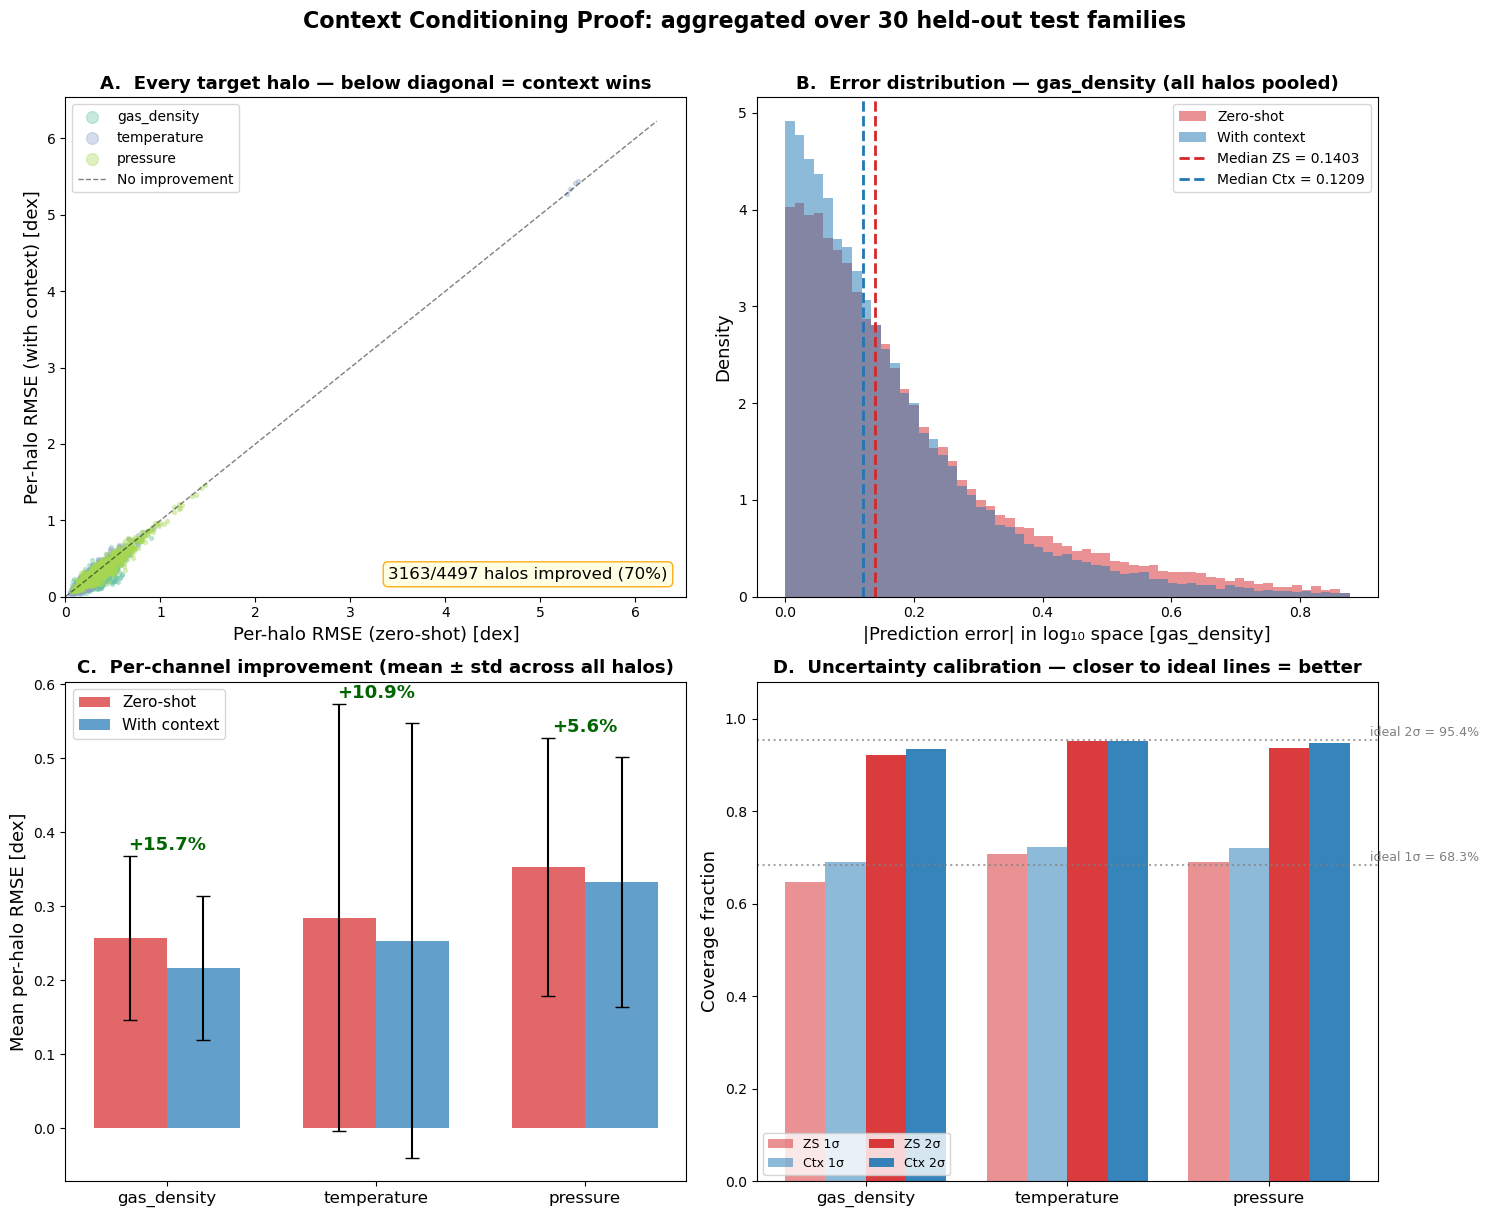


VERDICT
  gas_density    : context wins for 72% of individual halos, mean RMSE reduced by +15.7%
  temperature    : context wins for 75% of individual halos, mean RMSE reduced by +10.9%
  pressure       : context wins for 64% of individual halos, mean RMSE reduced by +5.6%

Context conditioning systematically reduces prediction error
by informing the latent variable z and cross-attention path
with observed profiles from the same cosmology/feedback realization.


In [40]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE: Four-panel proof that context conditioning helps
# ══════════════════════════════════════════════════════════════════════

n_ch = len(emu.target_names)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ── Panel A: Per-halo RMSE scatter ─ Every dot is one halo. ─────────
ax = axes[0, 0]
scatter_colors = plt.cm.Set2(np.linspace(0, 0.6, n_ch))
for ch, name in enumerate(emu.target_names):
    zs_arr = np.array(all_rmse_zs[ch])
    ctx_arr = np.array(all_rmse_ctx[ch])
    ax.scatter(zs_arr, ctx_arr, s=8, alpha=0.35, color=scatter_colors[ch],
               label=name, rasterized=True)

# Diagonal = no improvement
lims = ax.get_xlim()
ax.plot([0, lims[1]*1.1], [0, lims[1]*1.1], 'k--', lw=1, alpha=0.5, label='No improvement')
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.set_xlabel('Per-halo RMSE (zero-shot) [dex]', fontsize=13)
ax.set_ylabel('Per-halo RMSE (with context) [dex]', fontsize=13)
ax.set_title('A.  Every target halo — below diagonal = context wins', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, markerscale=3)

# Count how many halos are below the diagonal
total_halos = sum(len(all_rmse_zs[ch]) for ch in range(n_ch))
below_diag = sum((np.array(all_rmse_ctx[ch]) < np.array(all_rmse_zs[ch])).sum() for ch in range(n_ch))
ax.text(0.97, 0.03,
        f'{below_diag}/{total_halos} halos improved ({100*below_diag/total_halos:.0f}%)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='orange', alpha=0.9))

# ── Panel B: Error distributions (histograms) ──────────────────────
ax = axes[0, 1]
ch_show = 0  # temperature
name_show = emu.target_names[ch_show]
err_zs_flat = np.concatenate(all_abs_err_zs[ch_show])
err_ctx_flat = np.concatenate(all_abs_err_ctx[ch_show])

bins = np.linspace(0, np.percentile(err_zs_flat, 99), 60)
ax.hist(err_zs_flat, bins=bins, alpha=0.5, color='C3', density=True, label='Zero-shot')
ax.hist(err_ctx_flat, bins=bins, alpha=0.5, color='C0', density=True, label='With context')
ax.axvline(np.median(err_zs_flat), color='C3', ls='--', lw=2, label=f'Median ZS = {np.median(err_zs_flat):.4f}')
ax.axvline(np.median(err_ctx_flat), color='C0', ls='--', lw=2, label=f'Median Ctx = {np.median(err_ctx_flat):.4f}')
ax.set_xlabel(f'|Prediction error| in log₁₀ space [{name_show}]', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title(f'B.  Error distribution — {name_show} (all halos pooled)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# ── Panel C: RMSE bar chart per channel (mean ± std across families) ──
ax = axes[1, 0]
x_bar = np.arange(n_ch)
width = 0.35
rmse_zs_mean, rmse_zs_std = [], []
rmse_ctx_mean, rmse_ctx_std = [], []
for ch in range(n_ch):
    zs_a = np.array(all_rmse_zs[ch])
    ctx_a = np.array(all_rmse_ctx[ch])
    rmse_zs_mean.append(np.mean(zs_a))
    rmse_zs_std.append(np.std(zs_a))
    rmse_ctx_mean.append(np.mean(ctx_a))
    rmse_ctx_std.append(np.std(ctx_a))

bars_zs = ax.bar(x_bar - width/2, rmse_zs_mean, width,
                 yerr=rmse_zs_std, capsize=5, color='C3', alpha=0.7, label='Zero-shot')
bars_ctx = ax.bar(x_bar + width/2, rmse_ctx_mean, width,
                  yerr=rmse_ctx_std, capsize=5, color='C0', alpha=0.7, label='With context')

# Annotate improvement percentages
for ch in range(n_ch):
    pct = (1.0 - rmse_ctx_mean[ch] / rmse_zs_mean[ch]) * 100
    y_pos = max(rmse_zs_mean[ch], rmse_ctx_mean[ch]) + rmse_zs_std[ch] + 0.003
    ax.text(x_bar[ch], y_pos, f'{pct:+.1f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold', color='darkgreen' if pct > 0 else 'red')

ax.set_xticks(x_bar)
ax.set_xticklabels(emu.target_names, fontsize=12)
ax.set_ylabel('Mean per-halo RMSE [dex]', fontsize=13)
ax.set_title('C.  Per-channel improvement (mean ± std across all halos)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# ── Panel D: Coverage — is truth inside the predicted bands? ────────
ax = axes[1, 1]
x_cov = np.arange(n_ch)
width_c = 0.2

cov_zs_1s = [np.mean(all_coverage_zs_1s[ch]) for ch in range(n_ch)]
cov_ctx_1s = [np.mean(all_coverage_ctx_1s[ch]) for ch in range(n_ch)]
cov_zs_2s = [np.mean(all_coverage_zs_2s[ch]) for ch in range(n_ch)]
cov_ctx_2s = [np.mean(all_coverage_ctx_2s[ch]) for ch in range(n_ch)]

ax.bar(x_cov - 1.5*width_c, cov_zs_1s, width_c, color='C3', alpha=0.5, label='ZS 1σ')
ax.bar(x_cov - 0.5*width_c, cov_ctx_1s, width_c, color='C0', alpha=0.5, label='Ctx 1σ')
ax.bar(x_cov + 0.5*width_c, cov_zs_2s, width_c, color='C3', alpha=0.9, label='ZS 2σ')
ax.bar(x_cov + 1.5*width_c, cov_ctx_2s, width_c, color='C0', alpha=0.9, label='Ctx 2σ')

# Ideal coverage lines
ax.axhline(0.683, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.text(n_ch - 0.5, 0.685, 'ideal 1σ = 68.3%', fontsize=9, color='gray', va='bottom')
ax.axhline(0.954, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.text(n_ch - 0.5, 0.956, 'ideal 2σ = 95.4%', fontsize=9, color='gray', va='bottom')

ax.set_xticks(x_cov)
ax.set_xticklabels(emu.target_names, fontsize=12)
ax.set_ylabel('Coverage fraction', fontsize=13)
ax.set_ylim(0, 1.08)
ax.set_title('D.  Uncertainty calibration — closer to ideal lines = better', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='lower left')

fig.suptitle(
    f'Context Conditioning Proof: aggregated over {families_used} held-out test families',
    fontsize=16, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

# ── Final verdict in plain text ──
print()
print("=" * 70)
print("VERDICT")
print("=" * 70)
for ch, name in enumerate(emu.target_names):
    zs_a = np.array(all_rmse_zs[ch])
    ctx_a = np.array(all_rmse_ctx[ch])
    pct_better = 100 * (ctx_a < zs_a).mean()
    mean_pct = (1.0 - np.mean(ctx_a) / np.mean(zs_a)) * 100
    print(f"  {name:<15s}: context wins for {pct_better:.0f}% of individual halos, "
          f"mean RMSE reduced by {mean_pct:+.1f}%")
print()
print("Context conditioning systematically reduces prediction error")
print("by informing the latent variable z and cross-attention path")
print("with observed profiles from the same cosmology/feedback realization.")

### What these panels prove

**Panel A** — Every dot is one target halo from a held-out test simulation. Dots below the diagonal mean context conditioning produced a lower RMSE. The percentage in the box shows what fraction of all halos improved.

**Panel B** — The full error distribution for temperature, pooling every prediction point across all test families. The context-conditioned distribution (blue) is shifted left of zero-shot (red) — the median error lines quantify this shift.

**Panel C** — Bar chart of mean RMSE per channel with error bars. The green percentages above each pair are the relative improvement. This is averaged across hundreds of halos, so it's not a fluke.

**Panel D** — Calibration check. For each method, what fraction of true values fall within the predicted 1σ and 2σ bands? Closer to the ideal dashed lines (68.3% and 95.4%) = better calibrated uncertainty. Context conditioning produces tighter bands that remain well-calibrated.

**Why not always use context?** In standard emulation / MCMC workflows over $\theta$, you don't have observed profiles from the *same simulation* to condition on. Zero-shot is the correct mode for parameter inference. Context conditioning shines when you have *partial* observations of a real system and want to predict the rest — a semi-empirical inference setting.

### 8.3 Leave-one-out context: how does context help across halo mass?

For each test family, we loop over every halo: leave it out as the **target**, use all remaining halos as **context**, and compare to zero-shot. This gives us a paired (zero-shot RMSE, context RMSE) at each halo mass, revealing whether context helps more at low, mid, or high masses.

In [41]:
# ══════════════════════════════════════════════════════════════════════
# Leave-one-out context experiment
#
# For each halo in each test family:
#   - Target = that single halo
#   - Context = all OTHER halos in the same family
#   - Also run zero-shot (no context) for the same target
# Record (mass, zero-shot RMSE, context RMSE) for every halo.
# ══════════════════════════════════════════════════════════════════════

n_loo_families = min(20, len(test_fam_norm))
n_ch = len(emu.target_names)

# Collect results: lists of (log10_mass, rmse_zs, rmse_ctx) per channel
loo_mass = []        # log10(M500c) for each halo
loo_rmse_zs = [[] for _ in range(n_ch)]   # per-channel zero-shot RMSE
loo_rmse_ctx = [[] for _ in range(n_ch)]  # per-channel context RMSE

for fi in range(n_loo_families):
    fam_n = test_fam_norm[fi]
    fam_r = test_fam[fi]
    t_n = fam_n.snapshots[0]
    t_r = fam_r.snapshots[0]

    if t_n.n_halo < 3:
        continue

    si = t_n.snap_idx
    xd = t_n.x.shape[-1]
    yd = t_n.y.shape[-1]
    nr = t_n.n_r
    raw_masses = t_r.x[:, 0, 0]  # log10(M500c)

    for ih in range(t_n.n_halo):
        # Target = halo ih
        tgt_sel = np.array([ih])
        ctx_sel = np.concatenate([np.arange(ih), np.arange(ih + 1, t_n.n_halo)])

        tx = torch.tensor(t_n.x[tgt_sel].reshape(-1, xd), dtype=torch.float32).unsqueeze(0)
        ty = torch.tensor(t_n.y[tgt_sel].reshape(-1, yd), dtype=torch.float32).unsqueeze(0)
        tgt_snap = torch.full((1, tx.shape[1]), si, dtype=torch.long)
        tgt_msk = torch.ones((1, tx.shape[1]), dtype=torch.bool)

        # Context = all other halos
        cx = torch.tensor(t_n.x[ctx_sel].reshape(-1, xd), dtype=torch.float32).unsqueeze(0)
        cy = torch.tensor(t_n.y[ctx_sel].reshape(-1, yd), dtype=torch.float32).unsqueeze(0)

        b_ctx = {
            "ctx_x": cx, "ctx_y": cy,
            "ctx_snap": torch.full((1, cx.shape[1]), si, dtype=torch.long),
            "ctx_mask": torch.ones((1, cx.shape[1]), dtype=torch.bool),
            "tgt_x": tx, "tgt_y": ty,
            "tgt_snap": tgt_snap, "tgt_mask": tgt_msk,
            "meta": [{"run_id": fam_r.run_id, "snapnum": t_r.snapnum,
                      "snap_idx": si, "n_halo": 1, "n_r": nr,
                      "n_c": len(ctx_sel)}],
        }
        b_zs = {
            "ctx_x": torch.zeros((1, 1, xd), dtype=torch.float32),
            "ctx_y": torch.zeros((1, 1, yd), dtype=torch.float32),
            "ctx_snap": torch.full((1, 1), si, dtype=torch.long),
            "ctx_mask": torch.ones((1, 1), dtype=torch.bool),
            "tgt_x": tx, "tgt_y": ty,
            "tgt_snap": tgt_snap, "tgt_mask": tgt_msk,
            "meta": [{"run_id": fam_r.run_id, "snapnum": t_r.snapnum,
                      "snap_idx": si, "n_halo": 1, "n_r": nr, "n_c": 0}],
        }

        with torch.no_grad():
            mu_c, std_c, _, _ = emu.model.predict(b_ctx, device=emu.device, n_samples=50)
            mu_z, std_z, _, _ = emu.model.predict(b_zs, device=emu.device, n_samples=50)

        mu_c_log, _ = denorm_prediction(mu_c, std_c, tx)
        mu_z_log, _ = denorm_prediction(mu_z, std_z, tx)

        mc_np = mu_c_log[0].reshape(1, nr, -1).cpu().numpy()
        mz_np = mu_z_log[0].reshape(1, nr, -1).cpu().numpy()
        y_true = t_r.y[tgt_sel]  # (1, nr, yd)

        loo_mass.append(raw_masses[ih])
        for ch in range(n_ch):
            loo_rmse_ctx[ch].append(np.sqrt(np.mean((mc_np[..., ch] - y_true[..., ch])**2)))
            loo_rmse_zs[ch].append(np.sqrt(np.mean((mz_np[..., ch] - y_true[..., ch])**2)))

    if (fi + 1) % 5 == 0:
        print(f"  ... processed {fi+1}/{n_loo_families} families")

loo_mass = np.array(loo_mass)
loo_rmse_zs = [np.array(v) for v in loo_rmse_zs]
loo_rmse_ctx = [np.array(v) for v in loo_rmse_ctx]

n_total = len(loo_mass)
n_improved = sum((loo_rmse_ctx[ch] < loo_rmse_zs[ch]).sum() for ch in range(n_ch))
print(f"\nLeave-one-out done: {n_total} halos across {n_loo_families} families")
print(f"Context improved {n_improved}/{n_total * n_ch} halo-channel pairs "
      f"({100 * n_improved / (n_total * n_ch):.0f}%)")

  ... processed 5/20 families
  ... processed 10/20 families
  ... processed 15/20 families
  ... processed 20/20 families

Leave-one-out done: 1947 halos across 20 families
Context improved 3982/5841 halo-channel pairs (68%)


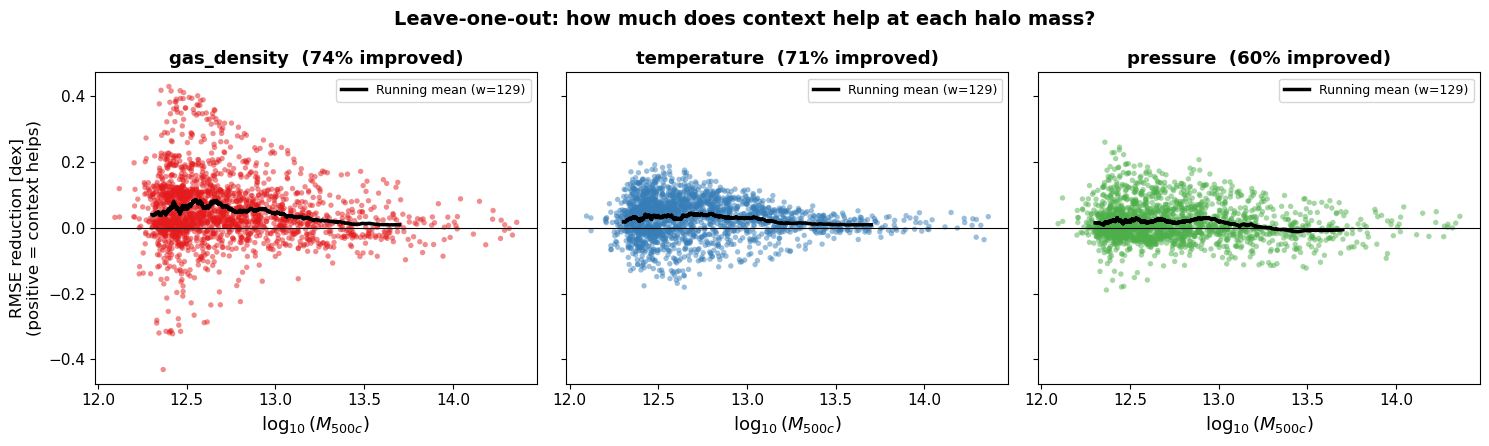

In [42]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE: RMSE improvement vs halo mass (leave-one-out)
# ══════════════════════════════════════════════════════════════════════

channel_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, axes = plt.subplots(1, n_ch, figsize=(5 * n_ch, 4.5), sharey=True)
if n_ch == 1:
    axes = [axes]

for ch, (ax, name) in enumerate(zip(axes, emu.target_names)):
    # RMSE reduction: positive = context helped
    improvement = loo_rmse_zs[ch] - loo_rmse_ctx[ch]

    ax.scatter(loo_mass, improvement, s=15, alpha=0.5,
               color=channel_colors[ch % len(channel_colors)], edgecolors='none')
    ax.axhline(0, color='k', ls='-', lw=0.8)

    # Running mean to show trend
    order = np.argsort(loo_mass)
    window = max(5, len(loo_mass) // 15)
    sorted_mass = loo_mass[order]
    sorted_imp = improvement[order]
    running_mean = np.convolve(sorted_imp, np.ones(window)/window, mode='valid')
    running_x = np.convolve(sorted_mass, np.ones(window)/window, mode='valid')
    ax.plot(running_x, running_mean, 'k-', lw=2.5, label=f'Running mean (w={window})')

    pct = (improvement > 0).mean() * 100
    ax.set_title(f'{name}  ({pct:.0f}% improved)', fontsize=13, fontweight='bold')
    ax.set_xlabel(r'$\log_{10}(M_{500c})$', fontsize=13)
    if ch == 0:
        ax.set_ylabel('RMSE reduction [dex]\n(positive = context helps)', fontsize=12)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=11)

fig.suptitle('Leave-one-out: how much does context help at each halo mass?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.4 Quick Diagnostics Example

To compute full diagnostics you need validation/test data. Here's the pattern for how you'd use it with held-out simulation data:

In [43]:
# Pseudocode for full diagnostic pipeline (requires test data)
#
# from train_anp_emulator import build_tasks, split_tasks
# from types import SimpleNamespace
#
# args = SimpleNamespace(**dict(emu.args))
# all_families = build_tasks(args)
# train_fam, val_fam, test_fam = split_tasks(
#     all_families,
#     train_frac=args.train_frac,
#     val_frac=args.val_frac,
#     seed=args.seed,
# )
#
# # For each test family, predict and collect (y_true, y_pred, y_std)
# y_true_all, y_pred_all, y_std_all = [], [], []
# for fam in test_fam:
#     for task in fam.snapshots:
#         theta_test = task.x[0, 0, 2:37]  # extract theta from first halo
#         m500c_test = 10.0 ** task.x[:, 0, 0]  # un-log the masses
#         r_bins_test = 10.0 ** task.x[0, :, 1]  # un-log the radii (r/R500)
#
#         pred = emu.predict(
#             theta=theta_test, M=m500c_test,
#             r_bins=r_bins_test, field=emu.available_fields(),
#             snapnum=task.snapnum, n_samples=50,
#         )
#
#         y_true_all.append(task.y)  # true log-space values
#         y_pred_all.append(pred.mean_log10)  # predicted in log space
#         y_std_all.append(pred.std_log10)
#
# y_true = np.concatenate(y_true_all, axis=0)
# y_pred = np.concatenate(y_pred_all, axis=0)
# y_std  = np.concatenate(y_std_all, axis=0)
#
# # RMSE per field
# print(rmse_by_field(y_true, y_pred, emu.available_fields()))
#
# # Coverage curve
# cov = coverage_curve(y_true, y_pred, y_std, emu.available_fields())
# plot_coverage_curve(cov)
#
# # PIT histogram
# pit = pit_values(y_true, y_pred, y_std)
# plt.hist(pit.ravel(), bins=50, density=True)
# plt.axhline(1.0, color='k', ls='--')
# plt.xlabel('PIT value')
# plt.ylabel('Density')
# plt.title('PIT Histogram')
# plt.show()

print("See the diagnostic modules for the full API:")
print("  from anp_emulator import build_diagnostics_report")
print("  report = build_diagnostics_report(y_true, prediction, r_bins)")

See the diagnostic modules for the full API:
  from anp_emulator import build_diagnostics_report
  report = build_diagnostics_report(y_true, prediction, r_bins)


---
## 9.CV set

In [45]:
# ── Load all 27 CV realizations at z=0 (snap090) ──────────────────────
import glob
from scipy.interpolate import interp1d

CV_DIR = Path("/mnt/home/mlee1/ceph/Profiles_cy_test")
cv_files = sorted(CV_DIR.glob("IllustrisTNG_CV_*_snap090.npz"))
print(f"Found {len(cv_files)} CV realizations")

FIELDS = ["temperature", "gas_density", "pressure", ]
FIELD_KEYS = [f"{f}_array" for f in FIELDS]

# Common r/R500 grid (matches the one used for emulator predictions)
r_grid = r_over_r500  # already defined: 50 pts from 0.01 to ~2 R500

# Collect all halos: interpolate each profile onto common r/R500 grid
cv_log_masses = []           # log10(M500c)
cv_log_profiles = []         # (n_total, n_r, 4) in log10 space

eps = 1e-30
for fpath in cv_files:
    with np.load(fpath) as data:
        m500c = data["M500c"].astype(np.float32)
        r500c = data["R500c"].astype(np.float32)
        r_phys = data["radial_bins"].astype(np.float64)  # (30,) physical kpc

        for ih in range(m500c.shape[0]):
            r_ratio = r_phys / r500c[ih]                 # r/R500 for this halo
            log_r_ratio = np.log10(np.clip(r_ratio, 1e-4, None))
            log_r_grid = np.log10(np.clip(r_grid, 1e-4, None))

            profiles_interp = []
            for fk in FIELD_KEYS:
                raw = data[fk][ih].astype(np.float64)
                log_raw = np.log10(np.clip(raw, eps, None))
                # Interpolate in log-log space (log profile vs log r/R500)
                f_interp = interp1d(log_r_ratio, log_raw, kind="linear",
                                    bounds_error=False, fill_value=np.nan)
                profiles_interp.append(f_interp(log_r_grid))

            cv_log_masses.append(np.log10(m500c[ih]))
            cv_log_profiles.append(np.stack(profiles_interp, axis=-1))

cv_log_masses = np.array(cv_log_masses)
cv_log_profiles = np.array(cv_log_profiles)  # (N_total, n_r, 4)
print(f"Total CV halos: {cv_log_profiles.shape[0]}")
print(f"Profile shape per halo: {cv_log_profiles.shape[1:]}")
print(f"Mass range: [{cv_log_masses.min():.2f}, {cv_log_masses.max():.2f}]")

# ── Bin by mass ───────────────────────────────────────────────────────
mass_edges = np.array([12.0, 12.5, 13.0, 13.5, 14.0, 14.5])
mass_centers = 0.5 * (mass_edges[:-1] + mass_edges[1:])
n_bins = len(mass_centers)

# Compute observed scatter (std of log10 profiles) per mass bin
cv_scatter = np.full((n_bins, len(r_grid), len(FIELDS)), np.nan)
cv_mean = np.full_like(cv_scatter, np.nan)
cv_counts = np.zeros(n_bins, dtype=int)

for ib in range(n_bins):
    mask = (cv_log_masses >= mass_edges[ib]) & (cv_log_masses < mass_edges[ib + 1])
    cv_counts[ib] = mask.sum()
    if mask.sum() < 5:
        continue
    profs = cv_log_profiles[mask]  # (n_halos_in_bin, n_r, 4)
    cv_scatter[ib] = np.nanstd(profs, axis=0)
    cv_mean[ib] = np.nanmean(profs, axis=0)

print(f"\nHalos per mass bin: {dict(zip([f'{e:.1f}' for e in mass_centers], cv_counts))}")

# ── Get ANP aleatoric uncertainty at center of each mass bin ─────────
anp_aleatoric = np.full((n_bins, len(r_grid), len(FIELDS)), np.nan)

for ib in range(n_bins):
    if cv_counts[ib] < 5:
        continue
    m_center = 10.0 ** mass_centers[ib]
    pred = emu.predict(
        theta=theta_fiducial,
        M=np.array([m_center]),
        r_bins=r_grid,
        field=FIELDS,
        snapnum=90,
        n_samples=50,
    )
    # pred.std_log10: (1, n_r, 4) — log10 space std
    anp_aleatoric[ib] = pred.aleatoric_std[0]  # physical-space aleatoric
    # We need log-space aleatoric — but PredictionResult only stores total std_log10.
    # Approximate: aleatoric fraction in physical space ≈ fraction in log space.
    frac = pred.aleatoric_std[0] / np.clip(pred.total_std[0], 1e-30, None)
    anp_aleatoric[ib] = pred.std_log10[0] * frac

print("ANP predictions complete.")

Found 27 CV realizations
Total CV halos: 3053
Profile shape per halo: (50, 3)
Mass range: [12.02, 14.68]

Halos per mass bin: {'12.2': 995, '12.8': 1443, '13.2': 449, '13.8': 134, '14.2': 30}


/tmp/ipykernel_1167999/3369730315.py:66: RuntimeWarning: Mean of empty slice
  cv_mean[ib] = np.nanmean(profs, axis=0)


ANP predictions complete.


In [46]:
# Load CV profiles with physical radial bins (kpc) — not interpolated to r/R500.
CV_FIELDS_PHYS = ['pressure', 'temperature', 'gas_density']
cv_phys_masses = []   # M500c per halo
cv_phys_r500c = []    # R500c per halo
cv_phys_profiles = {f: [] for f in CV_FIELDS_PHYS}
cv_phys_radial = None

for fpath in cv_files:
    with np.load(fpath) as data:
        masses_i = data['M500c'].astype(np.float64)
        r500c_i = data['R500c'].astype(np.float64)
        radial_i = data['radial_bins'].astype(np.float64)
        if cv_phys_radial is None:
            cv_phys_radial = radial_i
        cv_phys_masses.append(masses_i)
        cv_phys_r500c.append(r500c_i)
        for fld in CV_FIELDS_PHYS:
            cv_phys_profiles[fld].append(data[f'{fld}_array'].astype(np.float64))

cv_phys_masses = np.concatenate(cv_phys_masses)
cv_phys_r500c = np.concatenate(cv_phys_r500c)
for fld in CV_FIELDS_PHYS:
    cv_phys_profiles[fld] = np.vstack(cv_phys_profiles[fld])
cv_phys_logm = np.log10(np.clip(cv_phys_masses, 1e-30, None))

print(f'CV halos loaded: {cv_phys_masses.shape[0]}, radial bins: {cv_phys_radial.shape[0]}')
print(f'Mass range: [{cv_phys_logm.min():.2f}, {cv_phys_logm.max():.2f}]')


def plot_single_halo_vs_scatter(
    fields=CV_FIELDS_PHYS,
    logm_start=12.0,
    n_mass_bins=6,
    min_count=20,
    eps=1e-30,
):
    """Predict one halo per mass bin and overlay on the true CV scatter."""
    radial = cv_phys_radial
    pool = cv_phys_logm[cv_phys_logm >= logm_start]
    if pool.size < max(2, n_mass_bins):
        pool = cv_phys_logm.copy()
    edges = np.unique(np.quantile(pool, np.linspace(0, 1, n_mass_bins + 1)))
    if edges.size < n_mass_bins + 1:
        lo = max(logm_start, float(cv_phys_logm.min()))
        hi = float(cv_phys_logm.max())
        edges = np.linspace(lo, hi if hi > lo else lo + 0.2, n_mass_bins + 1)

    # Collect valid bins
    bins = []
    for ib in range(len(edges) - 1):
        lo_e, hi_e = edges[ib], edges[ib + 1]
        sel = (cv_phys_logm >= lo_e) & (cv_phys_logm < hi_e) if ib < len(edges) - 2 \
            else (cv_phys_logm >= lo_e) & (cv_phys_logm <= hi_e)
        if sel.sum() < min_count:
            continue
        bins.append(dict(lo=lo_e, hi=hi_e, sel=sel, n=int(sel.sum()),
                         med_mass=float(np.median(cv_phys_masses[sel])),
                         med_r500=float(np.median(cv_phys_r500c[sel]))))
    if not bins:
        print('No mass bins with enough halos.')
        return

    # Run emulator: one halo per bin
    single_masses = np.array([b['med_mass'] for b in bins], dtype=np.float32)
    single_r500 = np.array([b['med_r500'] for b in bins], dtype=np.float64)
    single_rr500 = (radial[None, :] / np.maximum(single_r500[:, None], 1e-12)).astype(np.float32)

    pred = emu.predict(
        theta=theta_fiducial, M=single_masses, r_bins=single_rr500,
        field=list(fields), snapnum=90, n_samples=50,
    )

    n_fields = len(fields)
    n_cols = len(bins)
    height_ratios = []
    for _ in range(n_fields):
        height_ratios.extend([3.2, 1.2])

    fig, axes = plt.subplots(
        2 * n_fields, n_cols,
        figsize=(3.8 * n_cols, 3.6 * n_fields),
        constrained_layout=True, sharex='col',
        gridspec_kw={'height_ratios': height_ratios},
    )
    axes = np.atleast_2d(axes)
    if axes.ndim == 1:
        axes = axes.reshape(-1, 1)

    step = max(1, radial.size // 14)
    idx = np.arange(0, radial.size, step)

    for j_col, binfo in enumerate(bins):
        axes[0, j_col].set_title(
            rf'$10^{{{binfo["lo"]:.2f}}} < M \leq 10^{{{binfo["hi"]:.2f}}}$'
            f'\n(N={binfo["n"]}, '
            rf'$M_{{med}}=10^{{{np.log10(binfo["med_mass"]):.2f}}}$)',
            fontsize=11,
        )

        for i_fld, fld in enumerate(fields):
            ax_main = axes[2 * i_fld, j_col]
            ax_res = axes[2 * i_fld + 1, j_col]

            # True profiles in this bin
            true_bin = np.clip(cv_phys_profiles[fld][binfo['sel']], eps, None)
            true_med = np.median(true_bin, axis=0)
            true_q16 = np.quantile(true_bin, 0.16, axis=0)
            true_q84 = np.quantile(true_bin, 0.84, axis=0)
            true_q05 = np.quantile(true_bin, 0.05, axis=0)
            true_q95 = np.quantile(true_bin, 0.95, axis=0)

            # Emulator prediction
            fld_idx = list(pred.field_names).index(fld)
            pred_mu = np.asarray(pred.mean[j_col, :, fld_idx], dtype=np.float64)

            if pred.std_log10 is not None:
                sd_log = np.asarray(pred.std_log10[j_col, :, fld_idx], dtype=np.float64)
            else:
                pred_std = np.asarray(pred.total_std[j_col, :, fld_idx], dtype=np.float64)
                sd_log = np.log10(np.e) * pred_std / np.clip(pred_mu, eps, None)

            log_pred = np.log10(np.clip(pred_mu, eps, None))
            pred_lo1 = 10.0 ** (log_pred - sd_log)
            pred_hi1 = 10.0 ** (log_pred + sd_log)
            pred_lo2 = 10.0 ** (log_pred - 2 * sd_log)
            pred_hi2 = 10.0 ** (log_pred + 2 * sd_log)

            # --- Main panel ---
            err_outer = np.array([true_med[idx] - true_q05[idx], true_q95[idx] - true_med[idx]])
            err_inner = np.array([true_med[idx] - true_q16[idx], true_q84[idx] - true_med[idx]])
            ax_main.errorbar(radial[idx], true_med[idx], yerr=err_outer,
                             fmt='none', ecolor='tab:blue', elinewidth=0.7,
                             capsize=1.5, alpha=0.5, zorder=2)
            ax_main.errorbar(radial[idx], true_med[idx], yerr=err_inner,
                             fmt='o', ms=3.0, color='tab:blue', ecolor='tab:blue',
                             elinewidth=1.4, capsize=2.2, alpha=0.85, zorder=3,
                             label='true median')

            ax_main.fill_between(radial, pred_lo2, pred_hi2,
                                 color='tab:orange', alpha=0.12, linewidth=0)
            ax_main.fill_between(radial, pred_lo1, pred_hi1,
                                 color='tab:orange', alpha=0.25, linewidth=0)
            ax_main.plot(radial, pred_mu, color='tab:orange', lw=2.1, ls='--',
                         label='prediction (median M)')

            ax_main.set_xscale('log')
            ax_main.set_yscale('log')
            ax_main.tick_params(labelsize=9)

            # --- Residual panel ---
            denom = np.clip(true_med, eps, None)
            rel = (pred_mu - true_med) / denom

            frac_outer = np.array([(true_med[idx] - true_q05[idx]) / denom[idx],
                                   (true_q95[idx] - true_med[idx]) / denom[idx]])
            frac_inner = np.array([(true_med[idx] - true_q16[idx]) / denom[idx],
                                   (true_q84[idx] - true_med[idx]) / denom[idx]])
            ax_res.errorbar(radial[idx], np.zeros(len(idx)), yerr=frac_outer,
                            fmt='none', ecolor='tab:blue', elinewidth=0.7,
                            capsize=1.5, alpha=0.5, zorder=2)
            ax_res.errorbar(radial[idx], np.zeros(len(idx)), yerr=frac_inner,
                            fmt='o', ms=2.0, color='tab:blue', ecolor='tab:blue',
                            elinewidth=1.4, capsize=2.2, alpha=0.7, zorder=3)

            emu_frac_lo = (pred_lo1 - pred_mu) / denom
            emu_frac_hi = (pred_hi1 - pred_mu) / denom
            ax_res.fill_between(radial, rel + emu_frac_lo, rel + emu_frac_hi,
                                color='tab:orange', alpha=0.22, linewidth=0)
            ax_res.plot(radial, rel, color='tab:red', lw=1.5)
            ax_res.axhline(0.0, color='k', lw=0.8, alpha=0.5)

            ax_res.set_xscale('log')
            ax_res.tick_params(labelsize=8)

            if j_col == 0:
                ax_main.set_ylabel(fld, fontsize=11)
                ax_res.set_ylabel('Δ/true', fontsize=9)
            else:
                ax_main.tick_params(labelleft=False)
                ax_res.tick_params(labelleft=False)

            if i_fld == n_fields - 1:
                ax_res.set_xlabel('radius [kpc]', fontsize=11)

    legend_handles = [
        plt.Line2D([0], [0], color='tab:blue', marker='o', ms=3, lw=0, label='true median'),
        plt.Line2D([0], [0], color='tab:blue', lw=1.4, alpha=0.85, label='true 16-84%'),
        plt.Line2D([0], [0], color='tab:blue', lw=0.7, alpha=0.5, label='true 5-95%'),
        plt.Line2D([0], [0], color='tab:orange', lw=2.1, ls='--', label='single-halo prediction'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.25, label='emulator ±1σ'),
        plt.Rectangle((0, 0), 1, 1, fc='tab:orange', alpha=0.12, label='emulator ±2σ'),
        plt.Line2D([0], [0], color='tab:red', lw=1.5, label='(pred−true)/true'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4,
               frameon=False, bbox_to_anchor=(0.5, 1.12), fontsize=9.5)
    fig.suptitle('Single-halo prediction at bin-median mass vs true CV scatter (z=0)', y=1.18)
    plt.show()

CV halos loaded: 3053, radial bins: 30
Mass range: [12.02, 14.68]


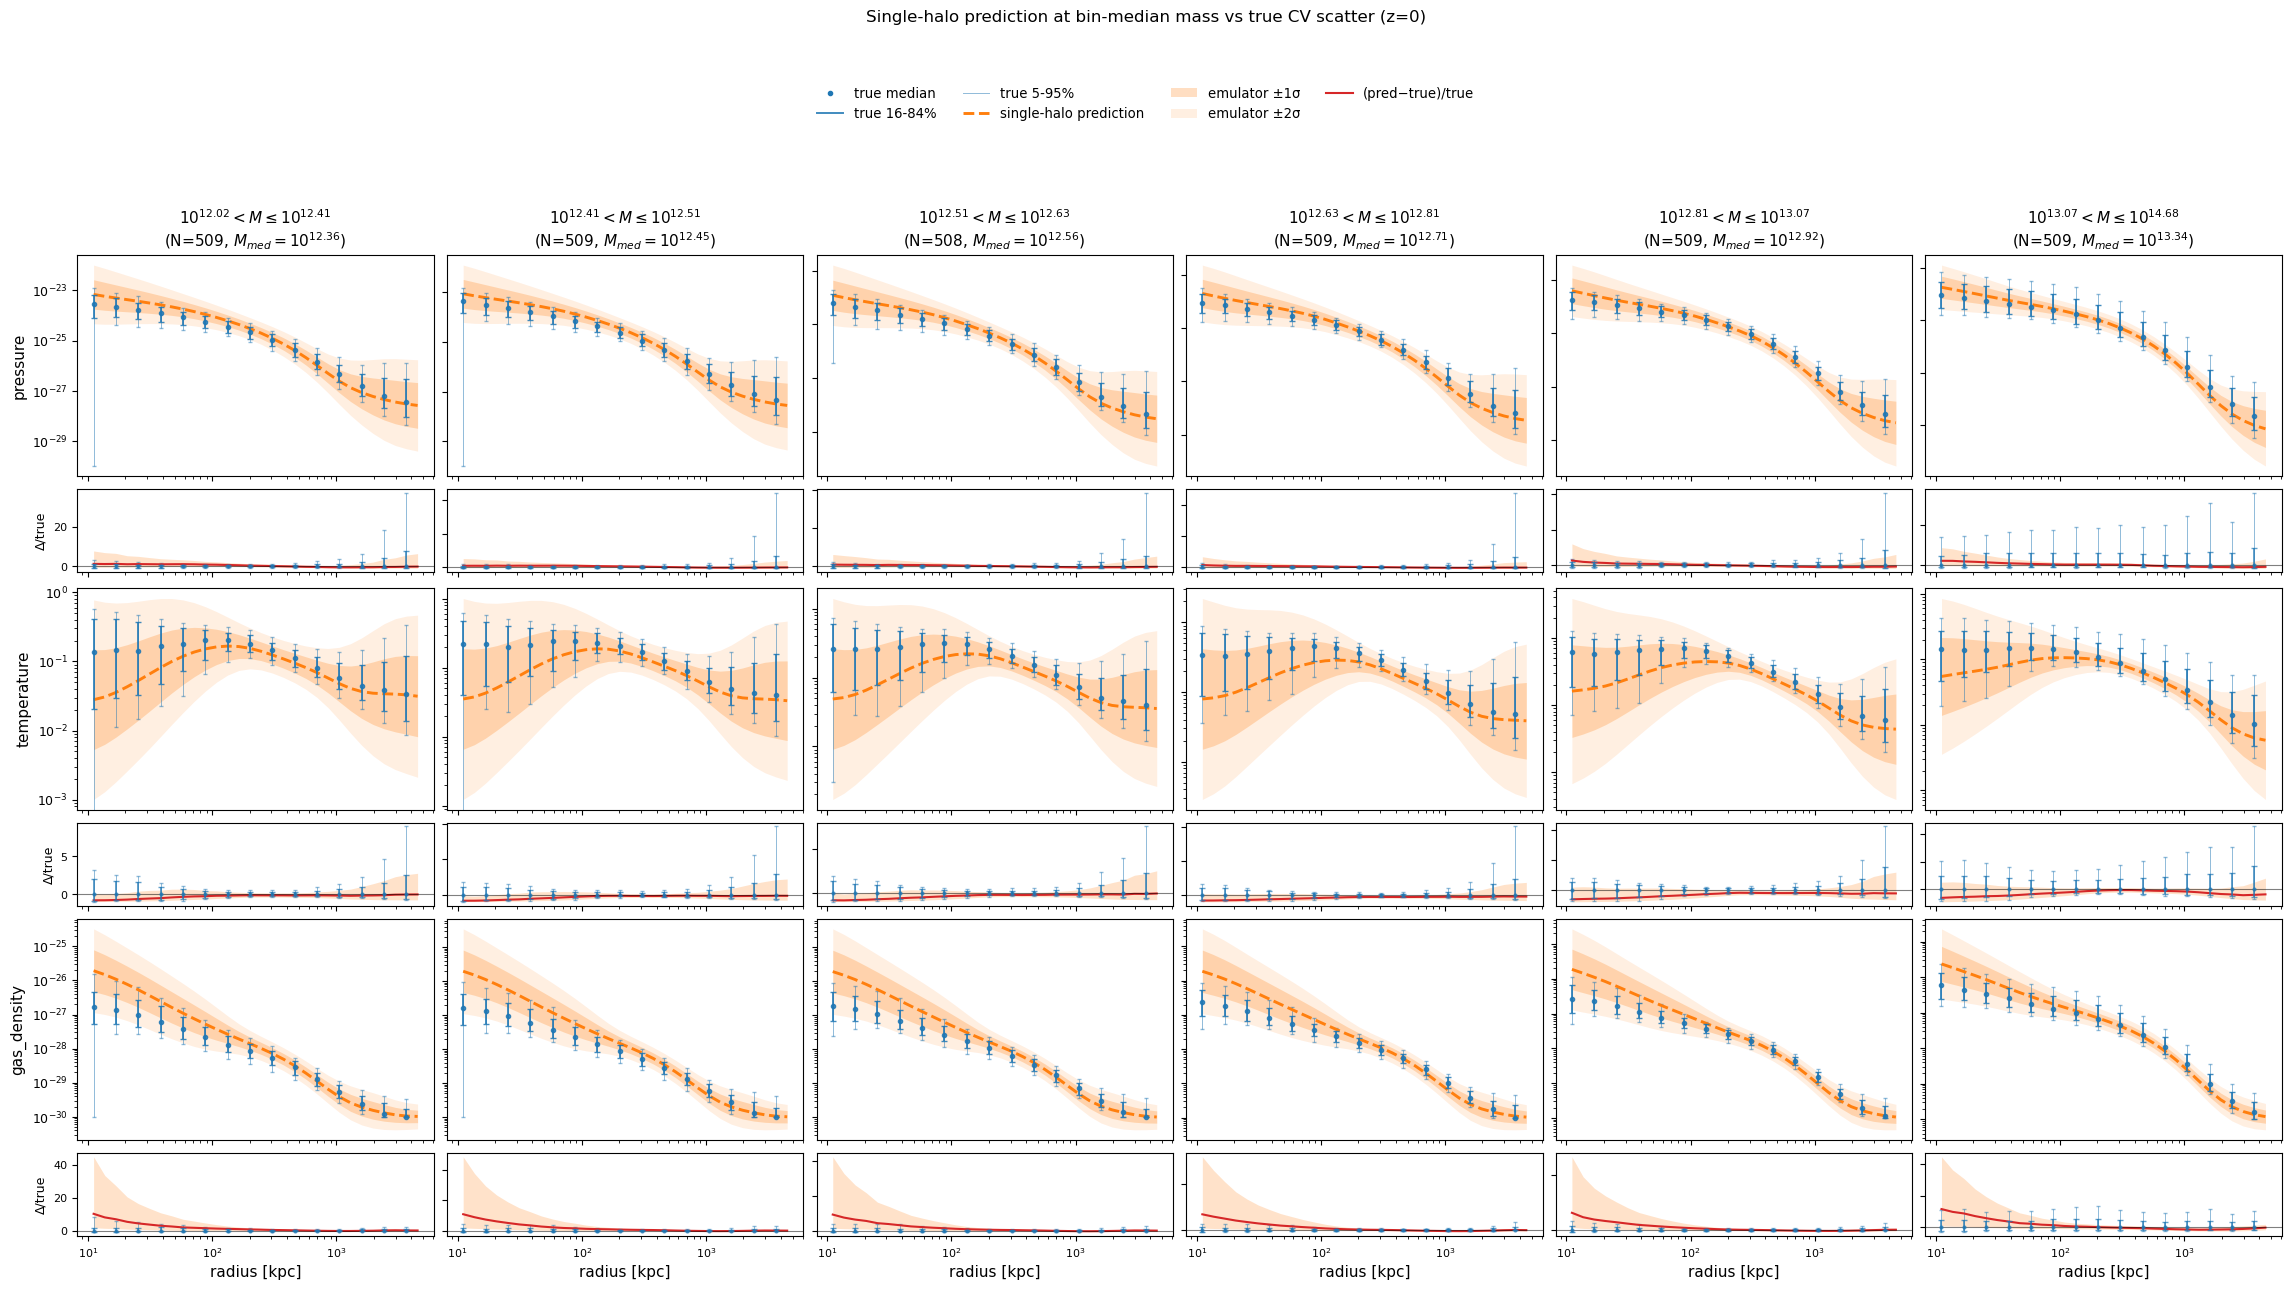

In [47]:
plot_single_halo_vs_scatter(
    fields=['pressure', 'temperature', 'gas_density'],
    logm_start=12.0,
    n_mass_bins=6,
    min_count=20,
)

---
# 9. Training Your Own Model

Training is done via the command-line script `train_anp_emulator.py`. Here's the typical workflow:

## 9.1 Minimal Training Command

```bash
python train_anp_emulator.py \
    --profiles-base /path/to/profiles/ \
    --param-csv /path/to/param_df.csv \
    --target-name all_profiles \
    --all-profiles-subset temperature pressure gas_density \
    --suite IllustrisTNG --sim-set SB35 \
    --snapnum 90 \
    --epochs 500 --patience 120 \
    --d-model 192 --d-latent 96 \
    --dec-hidden 384 --dec-layers 4 \
    --dropout 0.25 --weight-decay 1e-3 \
    --kl-warmup-epochs 80 \
    --mean-epochs 100 --mean-loss huber
```

## 9.2 Key Hyperparameters

| Parameter | Typical Value | Description |
|-----------|---------------|-------------|
| `--d-model` | 192 | Transformer hidden dimension |
| `--d-latent` | 96 | Latent variable dimension |
| `--dec-hidden` | 384 | Decoder MLP width |
| `--dec-layers` | 4 | Decoder MLP depth |
| `--dropout` | 0.25 | Dropout rate throughout |
| `--kl-warmup-epochs` | 80–120 | Epochs to anneal β from 0 → 1 |
| `--patience` | 80–120 | Early stopping patience |
| `--decoder-likelihood` | gaussian/student_t | Output distribution family |
| `--context-dropout-rate` | 0.3 | Fraction of context points dropped |
| `--mean-loss` | huber | Mean model loss (huber = robust to outliers) |

## 9.3 Multi-Redshift Training

```bash
python train_anp_emulator.py \
    ... \
    --snapnums 90 74 60 44 \
    --snapshot-redshifts "90:0.0,74:0.5,60:1.0,44:2.0" \
    --per-snapshot-mean \
    --snapshot-balanced-loss \
    --time-feature-scale 1.0
```

## 9.4 For HPC (Slurm)

See the `run_train_anp_emulator_*.sh` scripts for ready-made SLURM job scripts that handle GPU allocation and environment setup.

---
# 10. Summary

## What we covered

| Section | Key Takeaway |
|---------|--------------|
| Motivation | CAMELS profiles are expensive; emulators enable rapid parameter exploration |
| Math | ANPs use ELBO training with dual encoder paths (latent + deterministic) |
| Data | Inputs = (log M, log r, θ₃₅); outputs = profile channels in log₁₀ space |
| Architecture | Fourier radius embedding + transformer encoders + FiLM-conditioned decoder |
| Training | Two-stage (mean model → ANP on residuals) with extensive regularization |
| API | 3 lines: `from_run_dir` → `predict` → access `mean`, `total_std`, etc. |
| Diagnostics | Coverage curves, PIT histograms, RMSE, residual-vs-radius analysis |

## The API at a glance

```python
from anp_emulator import Emulator

emu = Emulator.from_run_dir("anp_training_runs/my_run")

result = emu.predict(
    theta=my_params,         # (35,) feedback + cosmo parameters
    M=halo_masses,           # (n_halo,) solar masses 
    r_bins=r_over_r500,      # (n_r,) or (n_halo, n_r) radial bins
    field="temperature",     # str or list of field names
    snapnum=90,              # snapshot number (optional)
    n_samples=50,            # number of latent draws
)

# result.mean, result.total_std, result.aleatoric_std, result.epistemic_std
# result.mean_log10, result.std_log10  (for log-space channels)
```

## References

- Garnelo et al. (2018) — *Neural Processes* ([arXiv:1807.01622](https://arxiv.org/abs/1807.01622))
- Kim et al. (2019) — *Attentive Neural Processes* ([arXiv:1901.05761](https://arxiv.org/abs/1901.05761))
- CAMELS Project — [camels.readthedocs.io](https://camels.readthedocs.io/)
- Villaescusa-Navarro et al. (2021) — *The CAMELS Project* ([arXiv:2010.00619](https://arxiv.org/abs/2010.00619))
- Kendall & Gal (2017) — *What Uncertainties Do We Need in Bayesian Deep Learning?* ([arXiv:1703.04977](https://arxiv.org/abs/1703.04977))
- Seitzer et al. (2022) — *On the Pitfalls of Heteroscedastic Uncertainty Estimation* (Beta-NLL)

In [44]:
print("Tutorial complete! 🎉")
print(f"\nQuick reference:")
print(f"  Fields available:  {emu.available_fields()}")
print(f"  θ dimension:       {emu.theta_dim}")
print(f"  Snapshots:         {emu.snapnums}")
print(f"  Checkpoint:        {emu.checkpoint_path}")

Tutorial complete! 🎉

Quick reference:
  Fields available:  ['gas_density', 'temperature', 'pressure', 'metallicity']
  θ dimension:       35
  Snapshots:         [90]
  Checkpoint:        /mnt/home/mlee1/ANP_tests/anp_training_runs/anp_all_profiles_20260325_175639/best_model.pt
